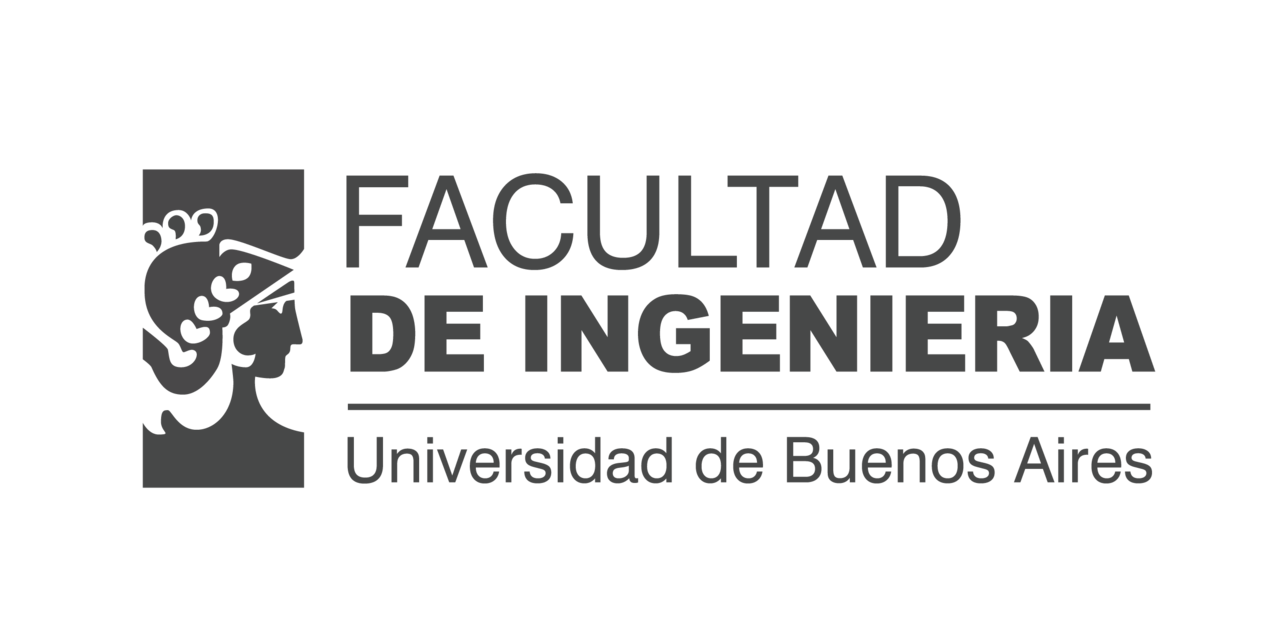

**Profesores:** <br />
Dr. Facundo Adrián Lucianna - facundolucianna@gmail.com <br />
Dr. Álvaro Gabriel Pizá - piza.ag@gmail.com <br />

**Alumnos:** <br />
Ing. Pablo Martin Gomez Verdini - gomezpablo86@gmail.com <br />
Ing. Diego Paciotti Iacchelli - diegopaciotti@gmail.com  <br />
Ing. Joaquin Gonzalez - joagonzalez@gmail.com <br />

**Repositorio Github**<br />
https://github.com/FIUBA-CEIA-18Co2024/AMIA-TP3 <br />


# TP integrador: Aprendizaje de Máquina 1

## Tabla de Contenido
1. [Propuesta de investigación](#Propuesta-de-investigación)
2. [Pipeline de trabajo](#Pipeline-de-trabajo)
3. [Pre procesamiento de los datos](#Pre-procesamiento-de-los-datos)
    1. [TfidfVectorizer](#TfidfVectorizer)
    2. [Exploración y balance de clases](#Exploración-y-balance-de-clases)
4. [Análisis de modelos](#Análisis-de-modelos)
5. [Busqueda de Hiper Parámetros](#Busqueda-de-Hiper-Parámetros)

# Propuesta de investigación

Para la realización de este trabajó se utilizará el dataset de **reviews** de estadía en hoteles de la empresa [Trip Advisor Hotel Reviews](https://www.kaggle.com/datasets/andrewmvd/trip-advisor-hotel-reviews). El objetivo es poder entrenar modelos que permitan realizar tareas de *sentiment analysis* de las reviews con el objetivo de poder utilizarlos, eventualmente para funcionalidades como:

- Categorización automática de comentarios en portales o sitios web para poner buenos comentarios en páginas de distintos productos
- Filtrar comentarios negativos para ser analizados, posteriormente, de forma manual por personal especializado y poder mejorar/modificar productos

Con el fin de trabajar con los temas vistos durante la cursada, nos propusimos hacer predicciones de puntuación de las reviews y luego compararlas con un análisis mas acotado de sentimientos **Negativos**, **Neutros** y **Positivos**.
Se realizó un fuerte trabajo en la preparación y normalización del dataset para ser utilizado en varios de los modelos vistos en clase.
Se eligió como línea base la regresión logística vista en Introducción a IA y se utilizaron para comparar clasificadores basados en SVM (kernel lineal y rbf) y Catboost. Adicionalmente algunos de estos modelos se usaron para hacer **ensemble** con la idea de compensar los puntos débiles entre ellos.

Se realizaron búsquedas de hiperparámetros con Optuna y GridSearch (sklearn) para obtener los mejores modelos y luego se los comparó en performance para poder obtener conclusiones. 

Se generan filas sintéticas extras con **Llama3-1B-Instruct** para balancear las clases. Estos datos se tomaron como reseñas nuevas, por lo que las muestras se utilizaran tanto para splits de train como de test. Esto de detalla en la sección de **Pipeline de trabajo** a continuación.

*Fuente Original*: https://www.kaggle.com/datasets/andrewmvd/trip-advisor-hotel-reviews

Con respecto a la organización del trabajo, en esta notebook se detallarán los resultados obtenidos, las justificaciones de los modelos y las conclusiones. El detalle de cada uno de estos puntos se encontrará en el resto de las notebooks adjuntadas:
- **aux_pre_processing.ipynb**: Tareas de limpieza y pre procesamiento de los datos para poder ser utilizado por los modelos seleccionados
- **aux_hiperparams_search.ipynb**: Búsqueda de hiperparámetros de los modelos principales utilizando Optuna
- **aux_inference_model_compare.ipynb**: Entrenamiento de los modelos seleccionados con los mejores hiperparámetros obtenidos en la notebook anterior

# Pipeline de trabajo

El proceso seguido para realizar el análisis de sentimientos del dataset de reviews de TripAdvisor consta de los siguientes pasos:

1. **Preparación de datos**:
   - Limpieza y preprocesamiento de las reviews.
2. **Extracción de características**:
   - Creación de una matriz dispersa utilizando TF-IDF.
3. **Reducción de dimensionalidad** (Cuando aporta buenos resultados):
   - Aplicación de TruncatedSVD para obtener una representación densa.
4. **Entrenamiento de modelos**:
   - Optimización de hiperparámetros mediante Optuna para SVC (lineal y RBF), CatBoost.
   - Uso de GridSearchCV para la regresión logística.
5. **Instanciación de modelos**:
   - Configuración de los modelos con los mejores parámetros encontrados.
6. **Comparación de modelos**:
   - Evaluación de los modelos y extracción de conclusiones.

# Pre procesamiento de los datos

En esta sección se implementa el pipeline de pre procesamiento de las reviews para homogeneizar los textos. Por ejemplo, se procedió a remover stopwords (palabras como conectores que son tan comunes que no agregaran información al modelo pero costarán computo procesarlas), stopwords de dominio, llevar todo a minúsculas, tratar multiples palabras concatenadas con wordninja para separarlas, remover caracteres especiales, normalizar el tratamiento de contracciones (para no tomar como cosas distintas won't y will not por ejemplo). De esta manera, a los modelos elegidos para entrenar en etapas posteriores les llegará un dataset normalizado y consistente.

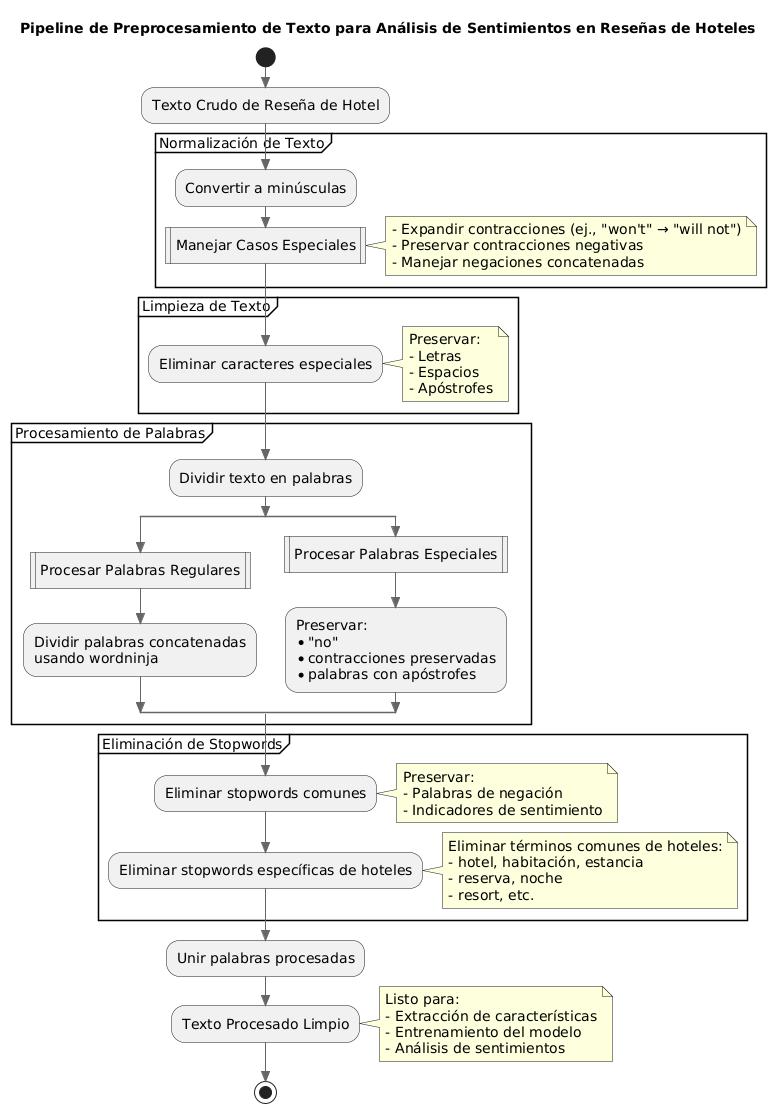

In [2]:
display(Markdown(preprocessing))

Debido a la calidad pobre de muchas reviews en el dataset (como la que se muestra en el ejemplo debajo de esta celda), y al desbalanceo que se ve en el histograma de esta sección, es que se deciden las siguientes modificaciones:

- Se realiza un drop de filas de clases mayoritarias 5 y 4 para trabajar el problema de desbalance y, al ser clases positivas en un extremo, son las que poseen menos lenguaje neutro. Por lo tanto, entendemos que tener menos filas no afectara considerablemente en la detección de los patrones necesarios para clasificarlas
- Se agregan reviews en las clases minoritarias 1, 2 y 3 respectivamente utilizando un LLM SoTA. Puntualmente, utilizamos **meta-llama/Llama3-1B-Instruct**. Los detalles de como se generaron estas reviews se observa en el apéndice de la notebook **pre_processing.ipynb**

A continuación, se puede observar la diferencia entre una review original y la versión post pipeline:

In [15]:
dataset = pd.read_csv('data/cleaned_dataset_processed_balanced.csv')
highlight_differences(dataset['review'][6], dataset['cleaned_review'][6])

### TfidfVectorizer

El `TfidfVectorizer` es una herramienta de preprocesamiento de texto de la librería `scikit-learn` que convierte un conjunto de documentos de texto en una matriz de características basada en el cálculo de la frecuencia inversa de término-documento (TF-IDF).

#### Principales componentes de TF-IDF
1. **TF (Term Frequency)**: Representa la frecuencia de un término en un documento, es decir, cuántas veces aparece una palabra en relación con el total de palabras en el documento.
2. **IDF (Inverse Document Frequency)**: Evalúa la importancia de un término en el corpus completo. Reduce el peso de palabras comunes que aparecen en muchos documentos, como palabras vacías (stopwords).

La fórmula para calcular el peso $\text{TF-IDF}(t, d)$ de un término $t$ en un documento $d$ es:
$$
\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \log\left(\frac{N}{1 + \text{DF}(t)}\right)
$$
Donde:
- $N$: Número total de documentos.
- $\text{DF}(t)$: Número de documentos que contienen el término $t$.

#### Funcionalidades principales
- **Normalización**: Los valores pueden ser normalizados para evitar que los documentos largos dominen las similitudes.
- **Stopwords**: Soporta la eliminación de palabras irrelevantes.
- **N-grams**: Puede considerar secuencias de palabras (bigramas, trigramas) como características.

#### Ventajas
- Capta la importancia relativa de las palabras en el contexto del documento y el corpus.
- Reduce el impacto de palabras comunes.

El `TfidfVectorizer` es fundamental para transformar datos textuales en características numéricas que los modelos de aprendizaje automático puedan procesar de manera efectiva.


### Exploración y balance de clases

Una visualización de WordCloud nos permitió ver cierta correlación entre las palabras utilizadas para clases positivas y negativas como se observa a continuación. Por otro lado, se detecta tanto por t-SNE como por la cantidad de reviews en la clase neutra que seguramente sea allí donde se presenten los mayores problemas para la clasificación. Esto se debe en parte, a que seguramente la neutralidad no tenga expresiones o palabras distintivas como si lo tengan las expresiones positivas o negativas y, en parte, a que hay muy pocas muestras ya que seguramente haya un sesgo de que hay poca motivación a dejar una recomendación cuando no se tiene nada que destacar. 

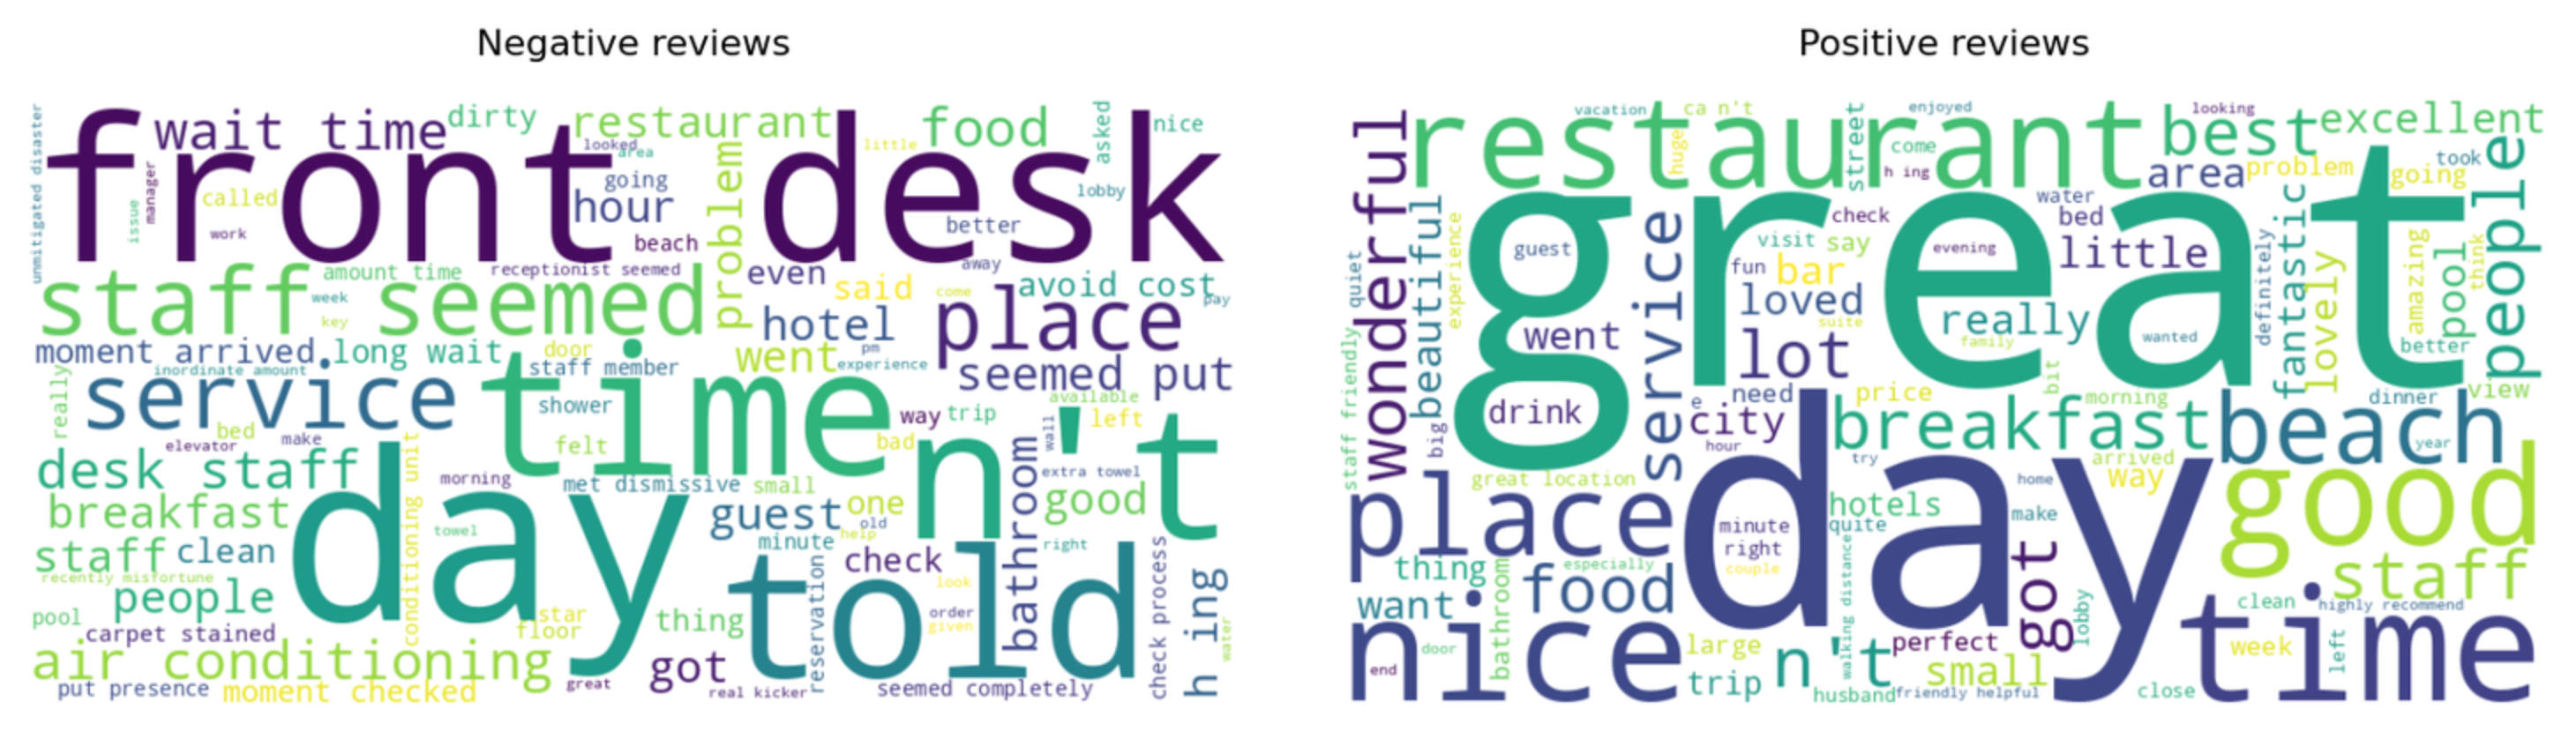

In [6]:
display(Markdown(word_cloud))

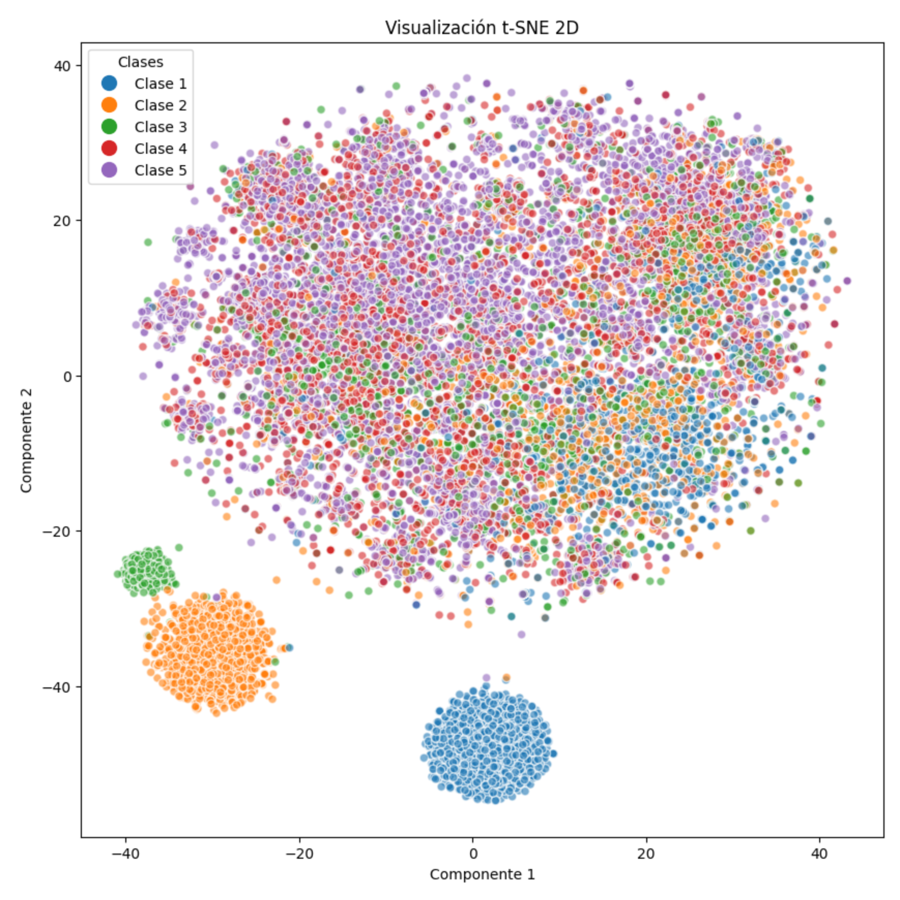

In [ ]:
display(Markdown(tsne))

En el diagrama siguiente, se muestran como quedaron los registros por clase post y pre agregado de registros con Llama3B. Si bien persiste cierto desbalance, no es tan considerable. Para ver el detalle de este procedimiento por favor revisar la notebook **pre_processing.ipynb**

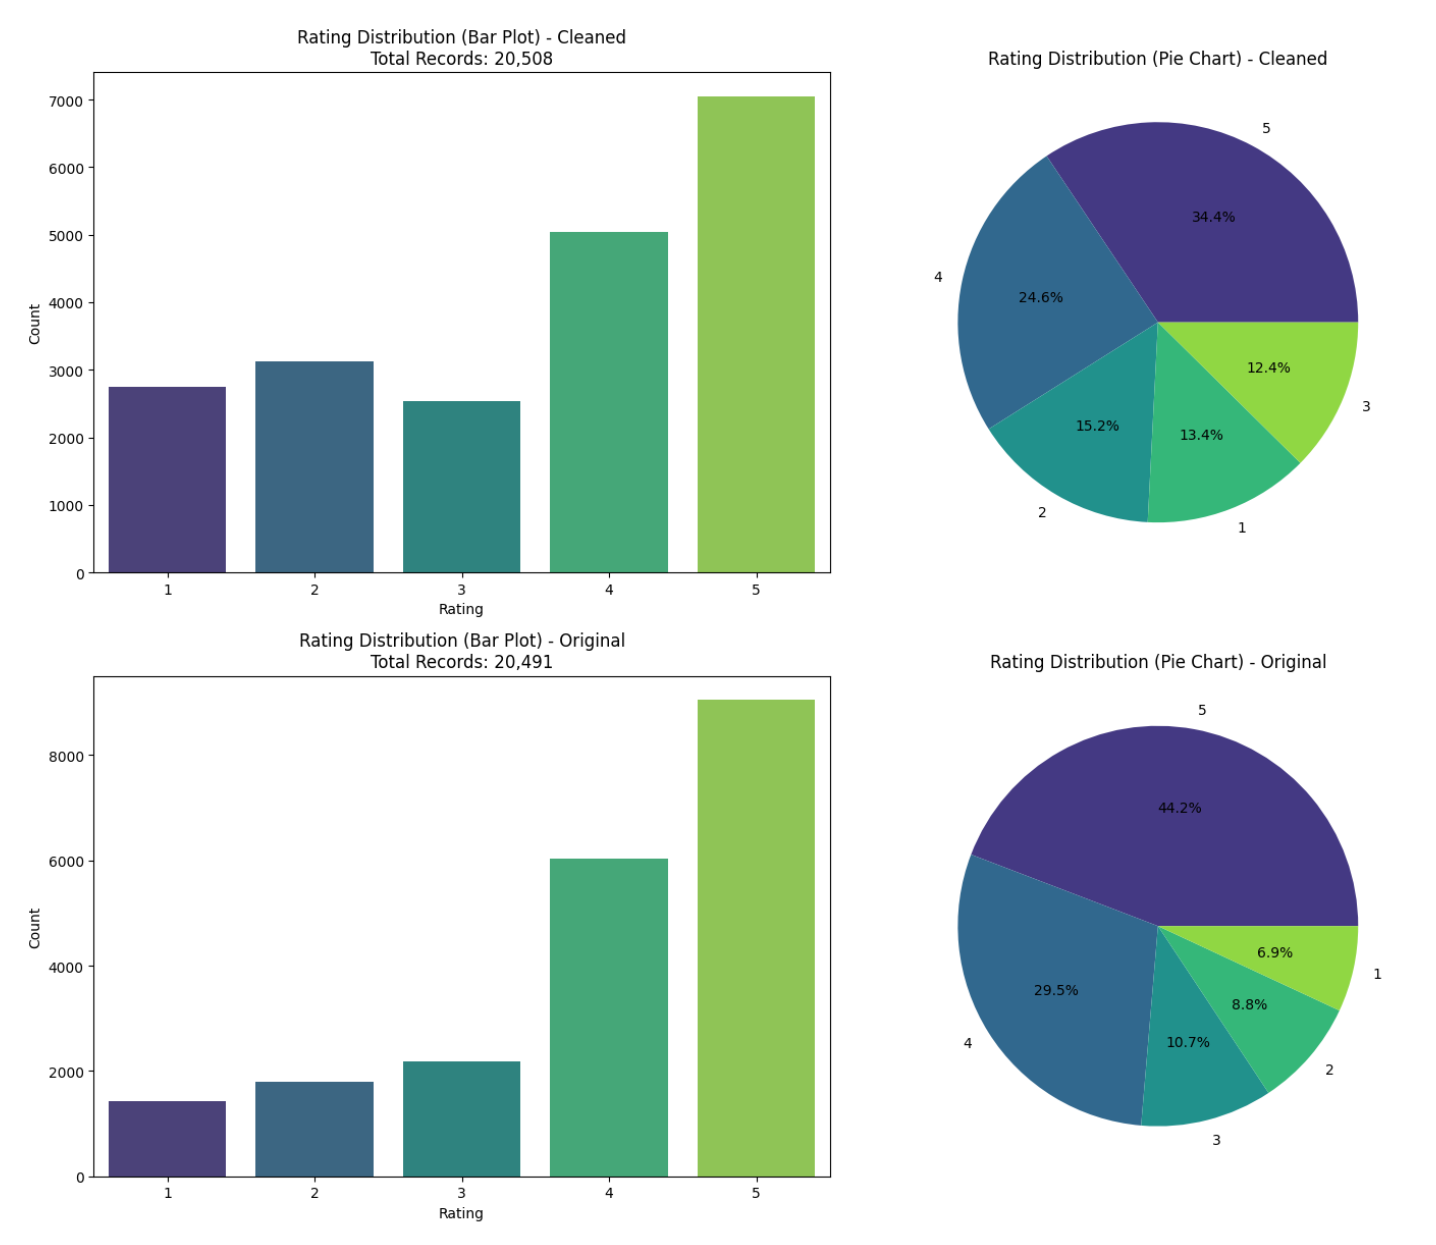

In [7]:
display(Markdown(pre_processing_classes))

# Análisis de modelos

#### Regresión Logística (LogisticRegression)
La regresión logística es un modelo de clasificación lineal que se utiliza para predecir la probabilidad de una clase en función de una o más características independientes. Funciona aplicando una función sigmoide a una combinación lineal de las características de entrada, lo que permite obtener una probabilidad entre 0 y 1. Es especialmente útil para problemas de clasificación binaria, pero también puede extenderse a problemas de clasificación multiclase.

**Justificación**: La regresión logística es un buen punto de partida debido a su simplicidad y capacidad para manejar problemas de clasificación. Proporciona una línea base interpretativa para comparar con modelos más complejos.

#### SVC lineal (LinearSVC)
El SVC lineal es una variante del Support Vector Machine (SVM) que utiliza un kernel lineal. Este modelo busca encontrar el hiperplano que mejor separa las clases en el espacio de características. Es eficiente para problemas de clasificación lineal y es adecuado para conjuntos de datos grandes debido a su rapidez.

**Justificación**: El SVC lineal es adecuado para problemas donde las clases son linealmente separables. Su simplicidad y velocidad lo hacen ideal para obtener resultados rápidos y establecer una línea base para modelos más complejos.

#### SVC RBF (SVC)
El SVC con kernel RBF (Radial Basis Function) es una variante del SVM que utiliza un kernel no lineal. Este modelo es capaz de capturar relaciones complejas entre las características de entrada al proyectarlas en un espacio de mayor dimensión. Es especialmente útil cuando las fronteras de decisión no son lineales. Se obervó que podían ser de especial utilidad al realizar t-SNE sobre el conjunto de datos, donde algunas clases se visualizaban como separables, no obstante esta técnica también advertía sobre ciertos problemas para discriminar o separar entre otras.

**Justificación**: El SVC RBF es adecuado para problemas donde las relaciones entre las características no son lineales. Su capacidad para capturar patrones complejos lo hace ideal para mejorar la precisión en problemas de clasificación difíciles.

#### Catboost (CatBoostClassifier)
CatBoost es un algoritmo de boosting basado en árboles de decisión que es especialmente eficiente para manejar características categóricas. Utiliza una técnica de ordenamiento para transformar las características categóricas en números y aplica boosting para mejorar iterativamente el rendimiento del modelo.

**Justificación**: CatBoost es ideal para problemas con características categóricas y grandes volúmenes de datos. Su capacidad para manejar automáticamente las características categóricas y su eficiencia en términos de tiempo de entrenamiento y soporte nativo para GPU lo hacen adecuado para este problema.

#### Ensemble (VotingClassifier)
El VotingClassifier es un modelo de ensamblaje que combina las predicciones de múltiples modelos base para mejorar la precisión general. Puede utilizar votación mayoritaria (hard voting) o votación ponderada por probabilidades (soft voting) para tomar la decisión final.

**Justificación**: El uso de un ensemble permite combinar las fortalezas de diferentes modelos base, compensando sus debilidades individuales. Esto puede resultar en un rendimiento general mejorado y una mayor robustez en la clasificación de las reviews.

# Busqueda de Hiper Parámetros

Como punto de partida se intentó realizar una representación de las variables con una reducción dimensional t-SNE, donde pudimos inferir que ciertas palabras era claves para poder discriminar entre sentimientos, pero que a su vez había muchas otras que se solapaban.

En la selección de los modelos para evaluar se utilizaron los siguientes criterios:
- Regresión Logística como línea base por su simplicidad y capacidad en los problemas de clasificación multinomial.
- SVC lineal por su simplicidad y velocidad, utilizando la estrategia OVO para mejorar las fronteras de clasificación
- SVC RBF, para poder clasificar en escenarios más complejos donde las fronteras lineales no pueden
- Catboost para utilizar los métodos de boosting en búsqueda de minimizar el error
- Ensemble con VotingClassifier para combinar las distintas características de los modelos.

Se implementaron dos técnicas principales para la optimización de hiperparámetros:

- **Optuna**: Se utilizó para encontrar los mejores hiperparámetros en los siguientes modelos:
  - SVC con kernel lineal.
  - SVC con kernel RBF.
  - CatBoost.
- **GridSearchCV**: Aplicado para la regresión logística debido a su simplicidad y naturaleza interpretativa. Dado que este modelo se utilizará de baseline de referencia no se realizó una optimización de hiperparámetros tan exhaustiva.

Los parámetros evaluados incluyeron:

- **SVC**: Regularización (C), kernel (lineal o RBF) y gamma (para RBF).
- **CatBoost**: Número de iteraciones, tasa de aprendizaje, y profundidad de árboles.
- **Regresión logística**: Parámetro y tipo de regularización (C) además de distintas técnicas para complementar el pre procesado.


# Inferencia de los modelos y comparaciones

Los modelos fueron instanciados con los mejores parámetros encontrados y evaluados utilizando métricas como:
- Accuracy
- Precisión.
- F1-score y F1-score weighted (por desbalance)
- Matriz de confusión.

Resultados destacados:

1. **SVC (Linear)**: gran velocidad del algoritmo, tanto training como predict, buena clasificación respecto a métodos mas complejos como RBF.
2. **CatBoost**: Mejor rendimiento en términos de rapidez y manejo de características categóricas, muy buena clasificación de las clases extremo.
3. **Regresión logística**: Resultado base interpretativo, modelo simple pero eficaz en la clasificación.

También se incluyó el tiempo de entrenamiento como parámetro a comparar en  la selección de modelos.

### Regresion Logística

Para este modelo que se utiliza de baseline, se realizaron tareas de optimización de hiperparámetros para 4 pipelines que se detallan en la figura adjuntada. Las variantes contemplan un modelo sin ningún tipo de agregado, uno con StandardScaler, otro con reducción de dimensionalidad y otro que combina las dos variantes anteriores. La idea inicial consistía en entender si alguna de estas técnicas provee mejoras en la capacidad de interpretación.

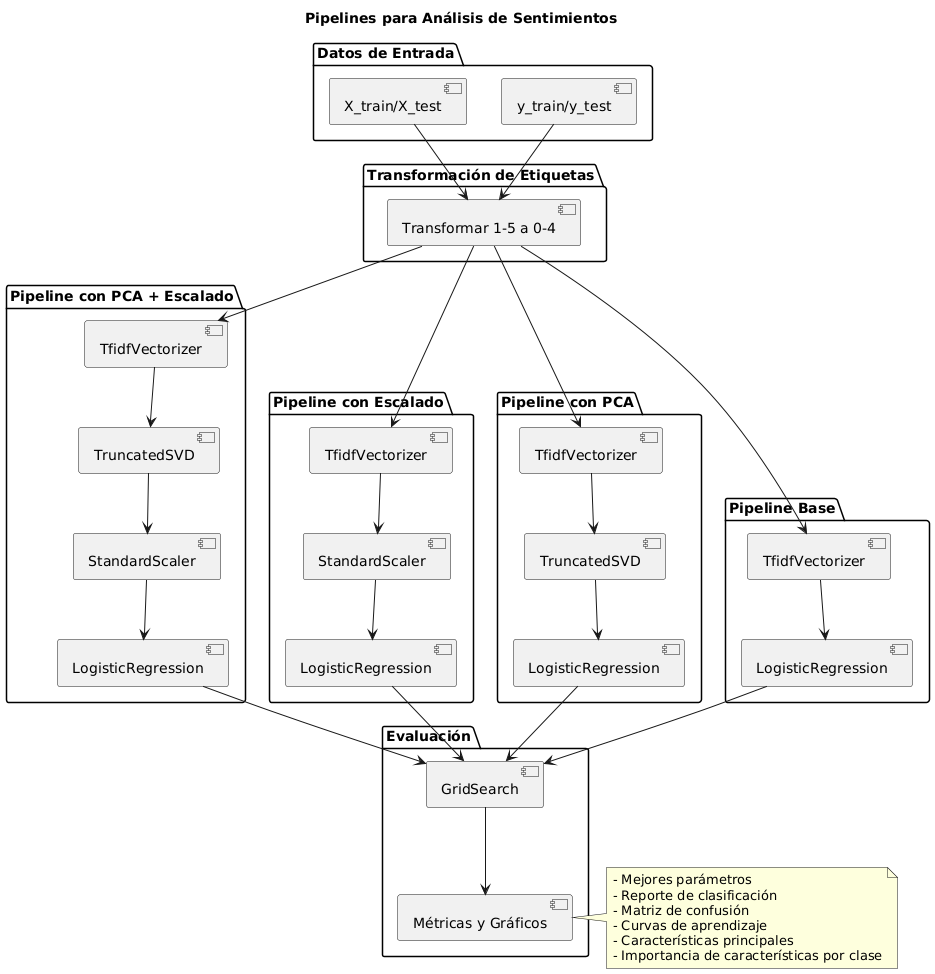

In [19]:
display(Markdown(logistic_regression_pipeline))

La mejor variante encontrada durante el proceso de búsqueda de hiperparámetros es la regresión logística sin reducción de dimensionalidad ni Scalers. Esto puede explicarse por las siguientes razones:


**Estandarización (StandardScaler)**:
- En el caso de texto, la estandarización podría no ser necesaria ya que los valores ya están normalizados de cierta manera por TFIDF
- Podría estar alterando relaciones importantes entre características que son naturalmente útiles para la clasificación

**PCA**:
- Aunque PCA reduce dimensionalidad, también puede estar perdiendo información valiosa específica que la regresión logística usa para discriminar entre clases
- Las componentes principales podrían no estar capturando los patrones más relevantes para la clasificación de reseñas

**Sobreajuste vs Simplicidad**:
- El modelo más simple (regresión logística sola) puede estar generalizando mejor
- Las transformaciones adicionales podrían estar introduciendo ruido o complejidad innecesaria

**Regularización Eficiente para Datos Balanceados**
- La opción `class_weight="balanced"` ajusta automáticamente los pesos de las clases en función de sus proporciones, lo que ayuda al modelo a manejar cualquier desbalance en las clases del dataset de TripAdvisor. Este ajuste pudo haber sido crucial para evitar sesgos hacia las clases mayoritarias.

**Preservación de información original**:
- La regresión logística directa puede estar aprovechando mejor las características originales del texto
- Las transformaciones podrían estar diluyendo señales importantes en los datos


Además, la brecha entre la puntuación de entrenamiento y la de validación indica un sesgo. Esto significa que el modelo no está sobreajustando, pero tampoco está capturando la complejidad de los datos.

Ambas curvas se estabilizan hacia la derecha, lo que sugiere que agregar más ejemplos ya no mejorará significativamente el rendimiento. Esto podría indicar que el modelo ha alcanzado su capacidad con las características y el algoritmo actuales.

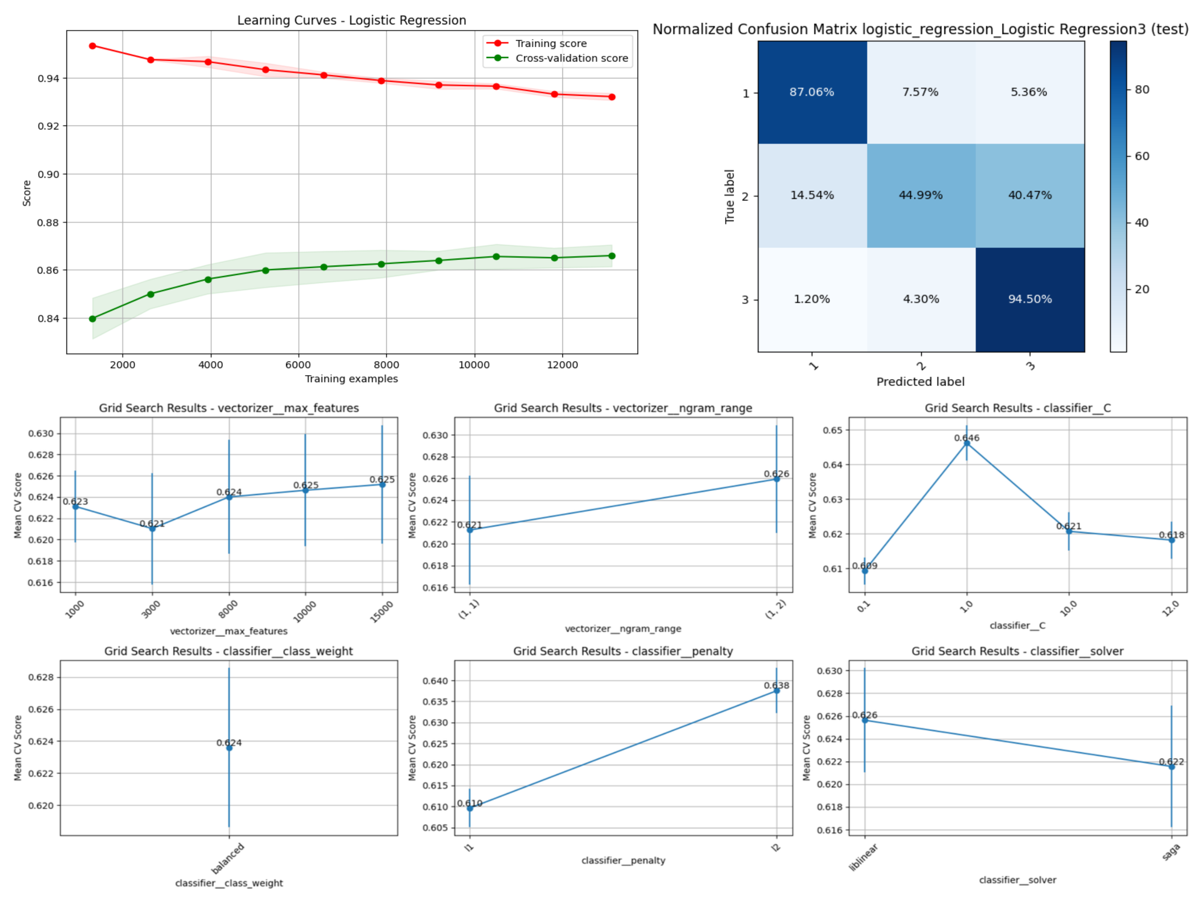

In [16]:
display(Markdown(logistic_regression_best))

Lo bueno de la regresión logística es que mantiene interpretabilidad. Aquí podemos ver las relaciones que establece para cada clase con respecto a las features en donde, por ejemplo, para la clase 1 (peor review) correlaciona positivamente con *not*, *dirty*, *worst* y negativamente con *good*, *clean*, *fantastic* lo cual da buenos indicios de lo patrones que el modelo es capaz de capturar de los datos.

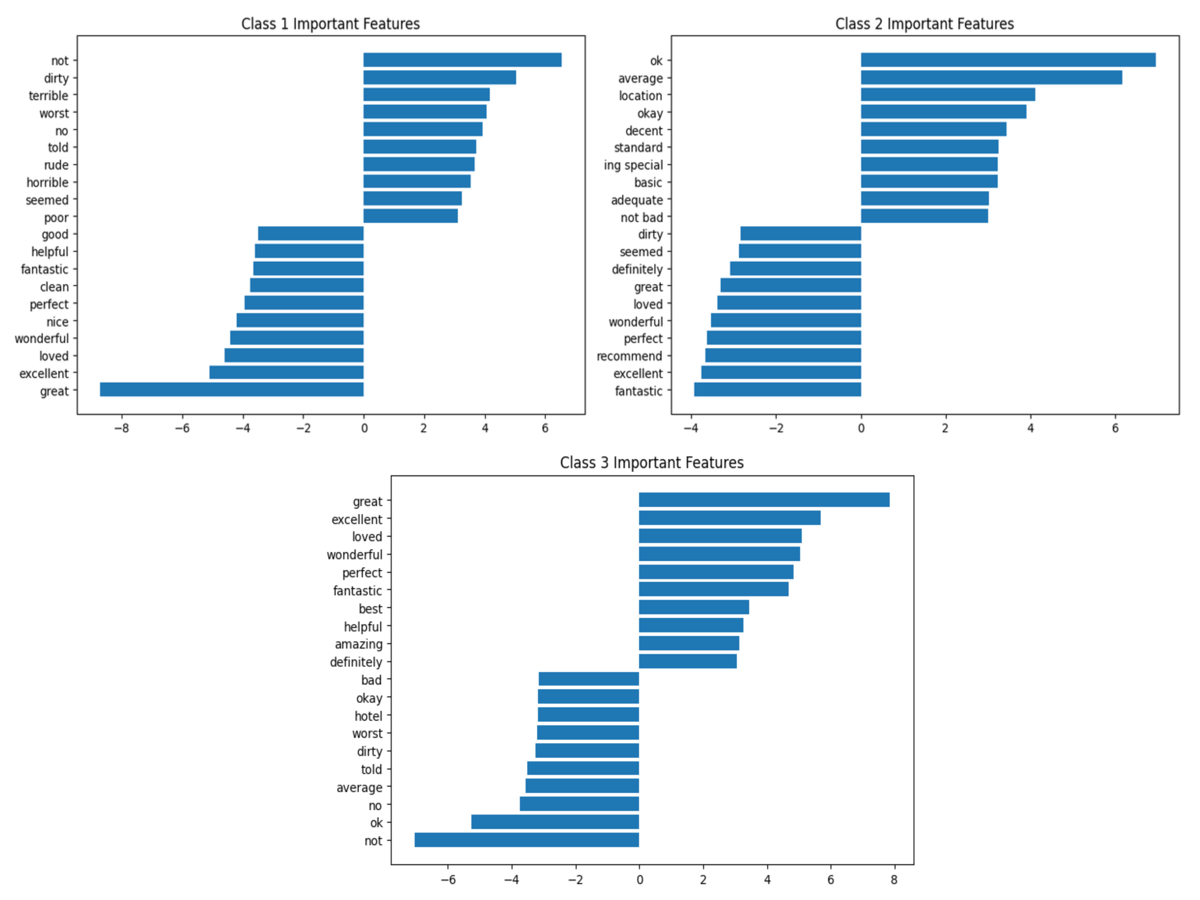

In [12]:
display(Markdown(logistic_regression_features))

Se puede ver que el mejor f1-score weighted fue para el pipeline de regresión logística sin agregados, con un promedio de 0.858 sobre conjunto de tests, el cual utilizaremos como baseline para el resto de los modelos.

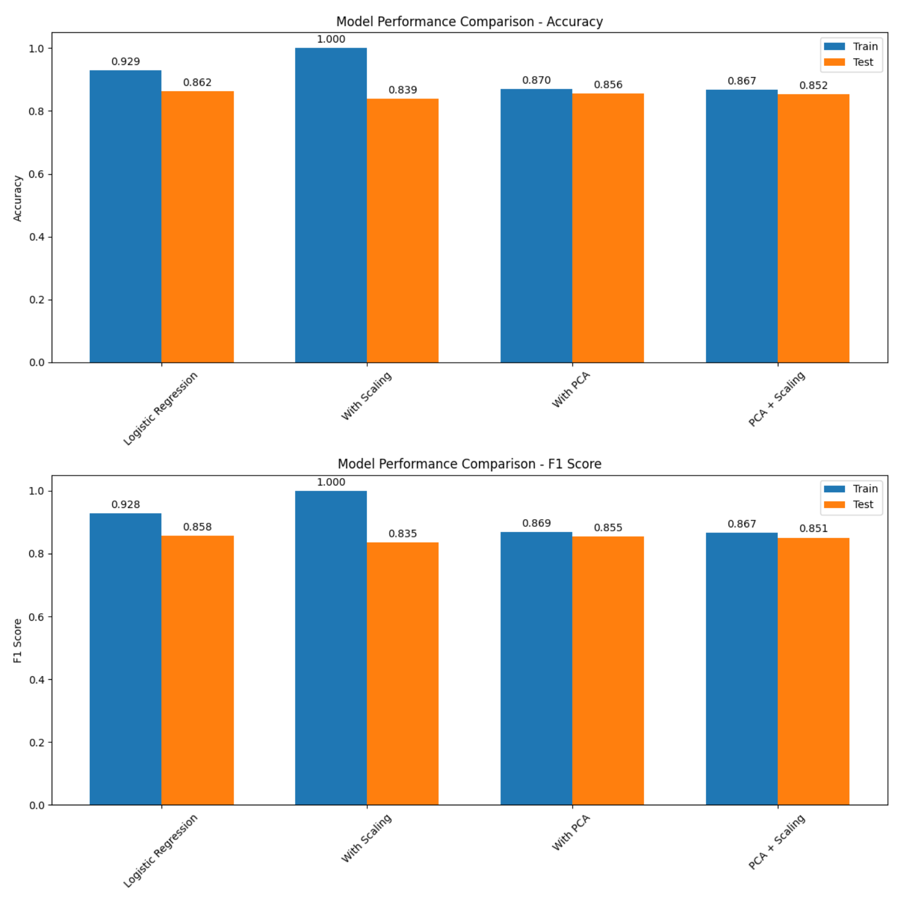

In [13]:
display(Markdown(logistic_regression))

### SVC y Catboost

Se realizó un análisis comparativo de modelos de clasificación multiclase aplicados a un problema de análisis de texto. Para ello, se diseñaron y evaluaron cuatro pipelines diferentes, cada uno integrando técnicas de procesamiento de texto, reducción de dimensionalidad y clasificación utilizando la información vista en la cursada.

Los modelos utilizados incluyen variantes del Support Vector Machine (SVM) con kernels lineal y no lineal, una implementación de clasificación basada en el algoritmo CatBoost, y una estrategia de clasificación multiclase mediante One-vs-One con LinearSVC.

La base del preprocesamiento de texto fue el uso de un vectorizador TF-IDF con parámetros ajustados que permiten capturar tanto palabras individuales como pares de palabras (bigramas). Adicionalmente, se aplicaron técnicas como escalado con MaxAbsScaler, reducción de dimensionalidad con TruncatedSVD y ajuste de hiperparámetros utilizando Optuna. El objetivo de este análisis fue identificar la configuración que mejor optimiza el desempeño en términos de precisión.

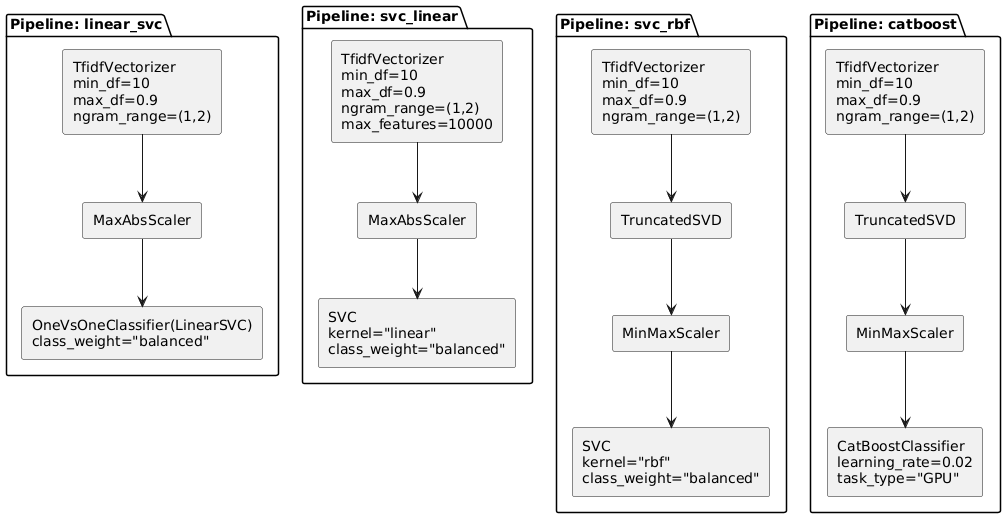

In [18]:
display(Markdown(catboost_svc_pipelines))

El modelo **LinearSVC** se destacó como el mejor entre los pipelines evaluados, obteniendo el puntaje más alto en las métricas de precisión, recall y F1-score, lo que indica un buen equilibrio entre la capacidad de identificar correctamente las clases y minimizar los errores. Este rendimiento superior puede explicarse por las siguientes razones:

**Manejo de Alta Dimensionalidad por LinearSVC**
- **LinearSVC**, al ser una implementación de Support Vector Machines con un kernel lineal, es particularmente efectivo para datos dispersos y de alta dimensionalidad, como los obtenidos de un vectorizador TF-IDF.
- En este caso, el modelo probablemente logró encontrar un hiperplano de separación óptimo en el espacio de características generadas por el TF-IDF, aprovechando las relaciones lineales entre las características.

**Sin Reducción de Dimensionalidad ni Pérdida de Información**
- En comparación con otros pipelines que aplicaron TruncatedSVD para reducir la dimensionalidad, el pipeline con **LinearSVC** mantuvo todas las características relevantes generadas por el TF-IDF, lo que podría haber contribuido a preservar información crítica para la clasificación.
- La reducción de dimensionalidad puede, en ciertos casos, eliminar señales útiles que el modelo necesita para discriminar entre clases.

**MaxAbsScaler Adaptado a Datos Dispersos**
- El uso de MaxAbsScaler fue apropiado dado que mantiene la forma dispersa de los datos TF-IDF y no altera las relaciones entre las características. Esto permitió que el modelo lineal explotara al máximo las representaciones originales sin introducir ruido o complejidad adicional.

**Regularización Eficiente para Datos Balanceados**
- La opción `class_weight="balanced"` ajusta automáticamente los pesos de las clases en función de sus proporciones, lo que ayuda al modelo a manejar cualquier desbalance en las clases del dataset de TripAdvisor. Este ajuste pudo haber sido crucial para evitar sesgos hacia las clases mayoritarias.

**Comparación con Modelos Más Complejos**
- **SVC con kernel RBF**: Aunque es más flexible, puede ser más propenso a sobreajustarse en datos dispersos como los de TF-IDF, especialmente si las características no son adecuadamente seleccionadas o si se pierde información relevante durante el escalado o la reducción de dimensionalidad.
- **CatBoostClassifier**: Este modelo, aunque poderoso, podría haber sido penalizado por la naturaleza dispersa de las características TF-IDF, que no siempre se alinean bien con las estructuras de decisión basadas en árboles.
- **SVC con kernel lineal**: Este modelo es similar a **LinearSVC**, pero puede ser menos eficiente en términos computacionales y podría haber sido afectado por las configuraciones específicas de hiperparámetros en este caso.

El pipeline con **LinearSVC** logró un equilibrio ideal entre simplicidad y rendimiento, aprovechando al máximo las características lineales del dataset preprocesado con TF-IDF y sin introducir transformaciones que pudieran diluir las señales útiles.

A continuación se muestran las matrices de confusión para el set de datos de train para 5 clases para el modelo **LinearSVC**. Se útilizo la Matriz con los datos de Train para tener parámetro del overfitting del modelo.

En las imágenes, se muestra un buen desempeño general, especialmente en las clases 1 y 5, que presentan las tasas más altas de precisión. Esto podría atribuirse a que estas clases contienen palabras determinantes como "Pésimo" o "Perfecto", que facilitan su identificación. Sin embargo, las clases intermedias (2, 3 y 4) presentan mayor confusión entre sí, especialmente en el conjunto de prueba, probablemente debido a una mayor superposición semántica en los textos asociados a estas categorías. La reclasificación en 3 clases podría ayudar a mitigar esta confusión.

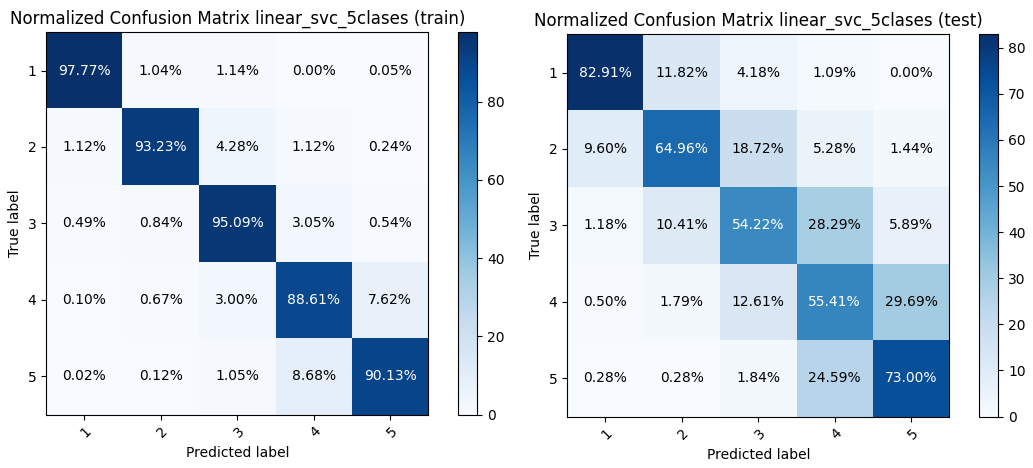

In [5]:
display(Markdown(LinearSVC_5clases_cm))

Y de manera similar se muestran las matrices de confusión para el set de datos de test para 5 clases para el modelo **LinearSVC**.

Puede observarse que la reclasificación en 3 clases demuestra una mejora en la capacidad del modelo para identificar opiniones positivas y negativas, reflejada en la alta precisión de las clases 1 y 3. Esto es coherente con el hecho de que, al unir las clases extremas (1 y 2 como negativas, y 4 y 5 como positivas), se aprovechan las palabras determinantes asociadas a estas opiniones ("Pésimo" para negativas y "Perfecto" para positivas).

Sin embargo, la clase 2 (neutral) sigue siendo la más desafiante de clasificar, obteniendo la tasa más baja de precisión. Esto se debe a la dificultad inherente, incluso para un humano, de identificar opiniones neutrales, ya que no existen palabras clave claras que las definan, lo que genera ambigüedad en el modelo. 

Esta simplificación de las clases permite al modelo centrarse en las categorías más claramente definidas, mejorando así su rendimiento global.

También se observa que al haber simplificado el problem ahora el modelo tiende a hacer overfitting sobre el conjunto de entrenamiento, especialmente para las clases neutras.


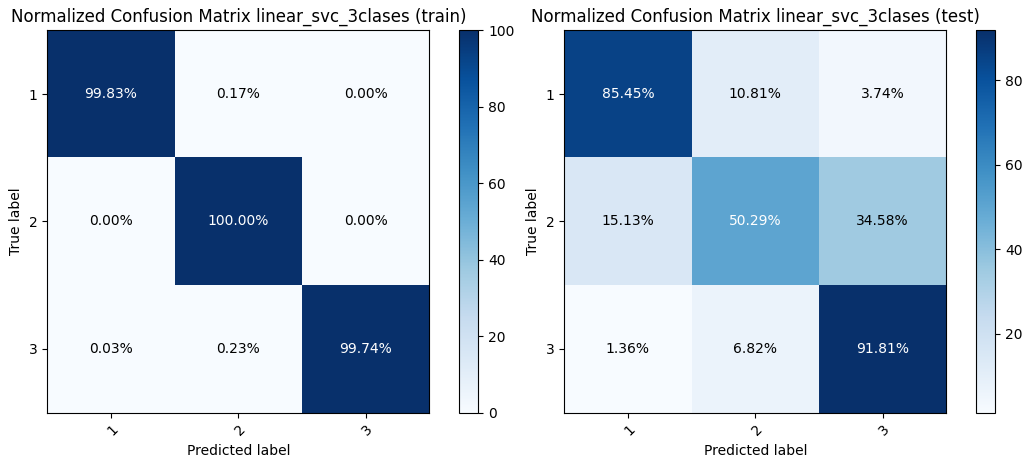

In [6]:
display(Markdown(LinearSVC_3clases_cm))

El pipeline con **SVC Linear** es una implementación **LibSVM** con kernel Linear, se comporta de forma similar a la implementación anterior (solo un poco mas de errores en las clasificaciones), solo que lleva mucho mas tiempo. Por otro lado este modelo tiene el método predict_proba útil para los ensemble con voting soft.

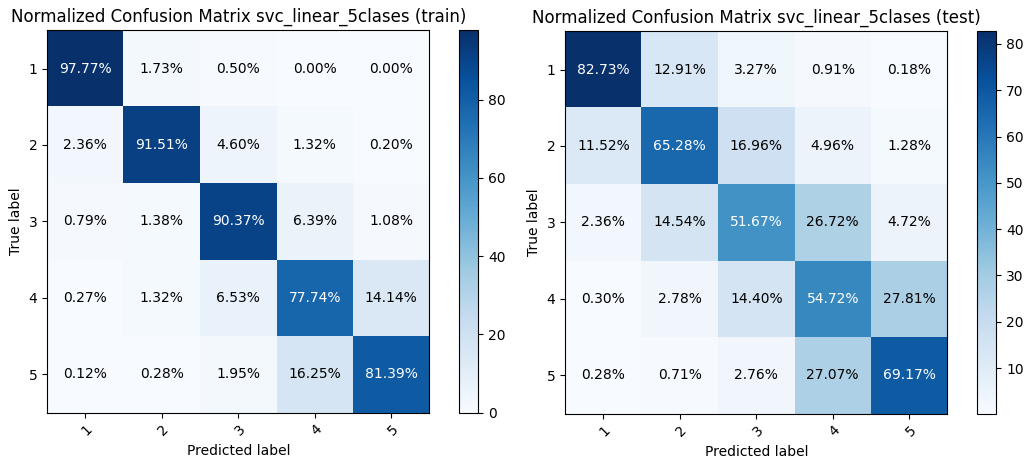

In [7]:
display(Markdown(SVCLinear_5clases_cm))

Puede observarse de la misma forma que en el caso anterior que la reclasificación en 3 clases demuestra una mejora en la capacidad del modelo para identificar opiniones positivas y negativas, reflejada en la alta precisión de las clases 1 y 3. 

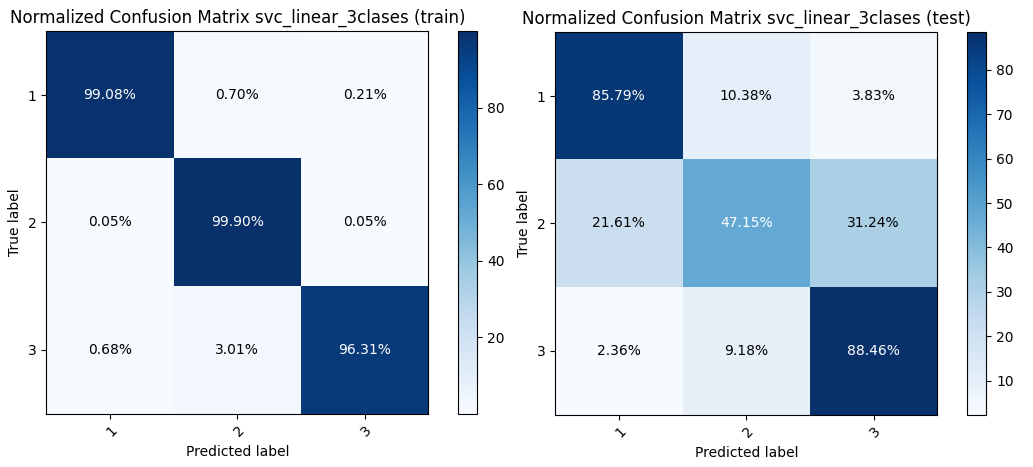

In [8]:
display(Markdown(SVCLinear_3clases_cm))

El pipeline con **SVC rbf** es una implementación **LibSVM** con kernel radial. Este método utiliza el kernel RBF para transformar los datos no lineales en un espacio de mayor dimensión, donde sea posible encontrar un hiperplano que los separe de manera lineal.
Características del kernel RBF:

- Capacidad no lineal:
    - El kernel RBF es especialmente útil cuando los datos no son linealmente separables. Proyecta los puntos de datos en un espacio de mayor dimensión mediante una función de similitud exponencial.

- Parámetros clave:
    - C (Regularización): Controla el equilibrio entre maximizar el margen y minimizar los errores de clasificación. Un valor alto de C penaliza más los errores, mientras que un valor bajo permite más errores pero busca un margen más amplio.
    - Gamma (γ): Determina la influencia de un punto de datos en los demás. Un valor alto de γ hace que cada punto tenga un impacto más localizado, mientras que un valor bajo suaviza la influencia entre puntos.

- Ventajas:
    - Puede manejar conjuntos de datos complejos con límites de decisión no lineales.
    - Es efectivo en problemas de clasificación con alta dimensionalidad.
    - El kernel RBF requiere ajustar solo dos hiperparámetros (C y γ), lo que facilita la optimización.

- Desventajas:
    - Sensible a la elección de los hiperparámetros. Requiere una búsqueda exhaustiva o validación cruzada para optimizar C y γ.
    - Puede ser costoso computacionalmente para grandes conjuntos de datos debido al cálculo de todos los pares de distancias.

Uso típico:
El SVC con kernel RBF se utiliza ampliamente en tareas como clasificación de imágenes, detección de anomalías, análisis de texto y problemas de biología computacional, donde los límites de decisión suelen ser no lineales y complejos.

En este caso particular se evidecia no pudo representar mejor el espacio que el kernel lineal.

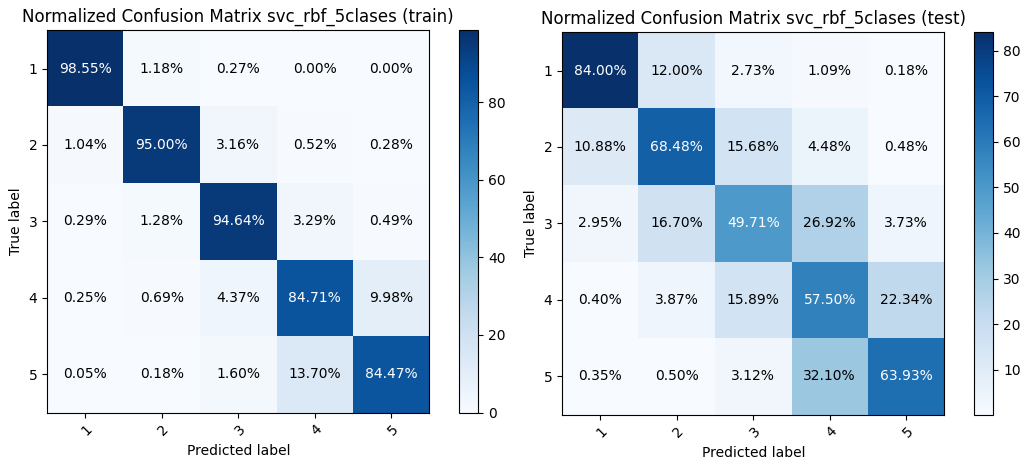

In [9]:
display(Markdown(SVCrbf_5clases_cm))

La reducción de las clases evidencia una mejoría en la clasificación de los modelos evaluados, para este caso tenemos el siguiente resultado.

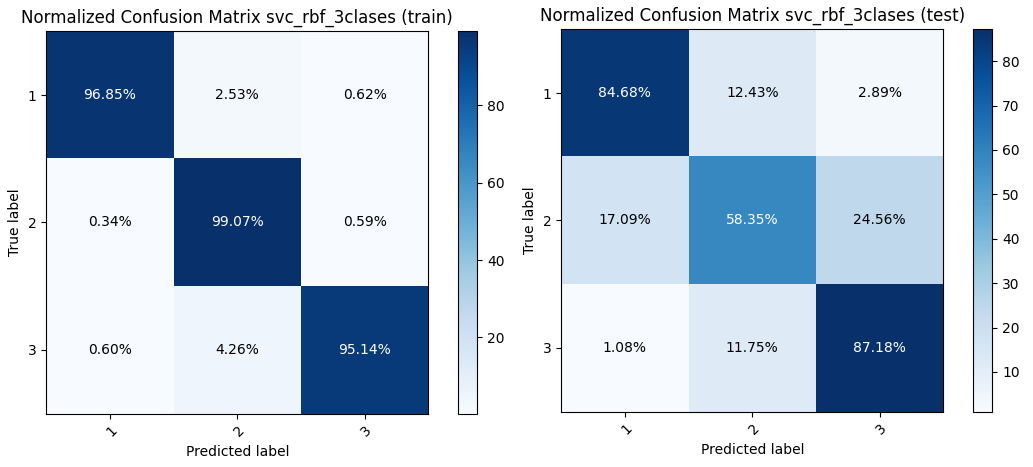

In [10]:
display(Markdown(SVCrbf_3clases_cm))

So optó por evaluar también **CatBoost** (Categorical Boosting) es una librería de aprendizaje automático basada en algoritmos de boosting sobre árboles de decisión. CatBoost es especialmente eficiente para trabajar con datos tabulares que contienen características categóricas y está diseñada para minimizar la necesidad de preprocesamiento de datos. Esta librería ademas soporta correrse sobre **GPU** lo que mejora mucho los tiempos de entrenamiento y predicción.

- Características principales

1. **Manejo eficiente de variables categóricas**:
   - CatBoost convierte automáticamente las variables categóricas a un formato numérico optimizado, utilizando técnicas como *target encoding* con regularización.


2. **Compatibilidad con múltiples tipos de tareas**:
   - Funciona bien tanto en problemas de regresión como de clasificación.
   - También es apto para problemas multiclase, ranking y predicciones por intervalos de confianza.

3. **Alta eficiencia y paralelización**:
   - Diseñado para ser rápido y eficiente gracias al uso de GPU, lo que lo hace adecuado para grandes conjuntos de datos.

- Ventajas

   - **Manejo automático de datos categóricos**, eliminando la necesidad de codificar manualmente.
   - **Robustez frente a valores faltantes** y escalado automático de características.
   - Compatible con GPU para acelerar el entrenamiento.
   - **Interpretable**: incluye herramientas integradas para analizar la importancia de las características.
   - **Rendimiento competitivo**: en muchas tareas, CatBoost supera a otros algoritmos como XGBoost y LightGBM, especialmente cuando hay muchas variables categóricas.


- Desventajas

   - Mayor tiempo de entrenamiento inicial comparado con otros algoritmos de boosting, aunque mitigado por su optimización en GPU.
   - Puede ser menos eficiente en conjuntos de datos donde no existen variables categóricas o donde los datos están completamente preprocesados.


- Parámetros importantes

   - **`iterations`**: Número de iteraciones o árboles a construir.
   - **`learning_rate`**: Tasa de aprendizaje que regula cuánto se ajustan los árboles sucesivos.
   - **`depth`**: Profundidad máxima de los árboles.
   - **`l2_leaf_reg`**: Regularización L2 para prevenir sobreajuste.
   - **`cat_features`**: Lista de columnas categóricas en el conjunto de datos.



- Casos de uso: CatBoost se utiliza en una variedad de aplicaciones, incluyendo:

   - **Análisis de datos tabulares**: Predicción de churn, análisis financiero, detección de fraude.
   - **Procesamiento de datos categóricos**: Sistemas de recomendación y clasificación de texto.
   - **Competencias de ciencia de datos**: Es una herramienta popular en plataformas como Kaggle debido a su excelente rendimiento fuera de la caja.

Lo que se pudo observar en las evaluaciones del modelo para este dataset, es que catboost predice muy bien las clases extremas pero tiene dificultades con las intermedias


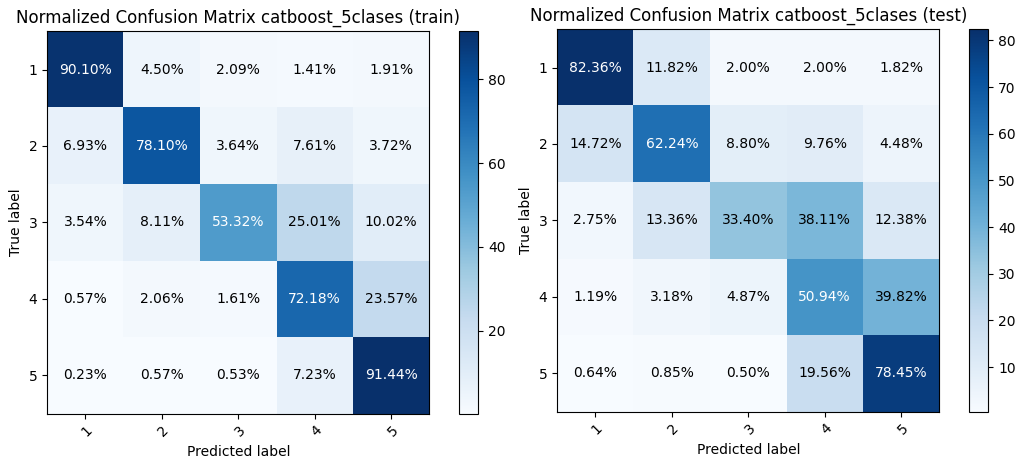

In [11]:
display(Markdown(catboost_5clases_cm))

Para el caso de 3 clases se evidencia un poco más esa dificultad con la neutralidad.

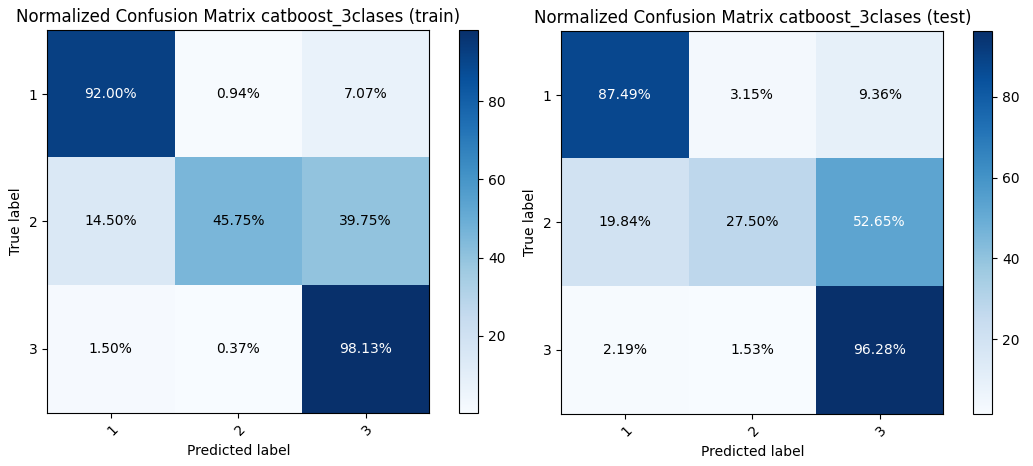

In [12]:
display(Markdown(catboost_3clases_cm))

A partir de estos resultados se probaron las técnicas de **Ensemble** con el VotingClassifier de Scikit Learn. Se buscó combinar los modelos de tal forma que se combinaran las fortalezas de cada uno. Se lograron leves mejorías en las predicciones, pero que no justifican el tiempo de entrenamiento y tener que mantener 3 modelos distintos.

Para el **Hard VottingClassifier** que obtiene el resultado a partir de la votación dura de las clases predichas por los modelos se utilizaron los siguientes modelos:
``` python
classifiers = [('LinearSVC', linear_svc), ('SVC RBF', svc), ('Catboost', catboost),]
```

Para el **Soft VottingClassifier** los modelos tienen que soportar el metodo de predict_proba, ya que este clasificado pondera la probabilidad con la que se predijo la clase, dando mas importancia a los modelos mas seguros:
``` python
classifiers = [('SVC', svc), ('SVC Linear', svc_linear), ('Catboost', catboost)]
```
Para la evaluación de las 5 clases tenemos el siguiente resultado:

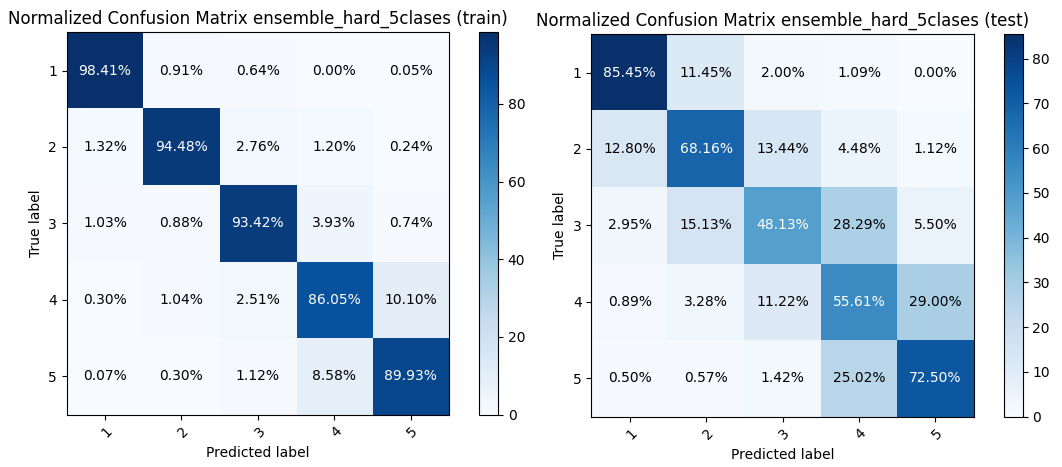

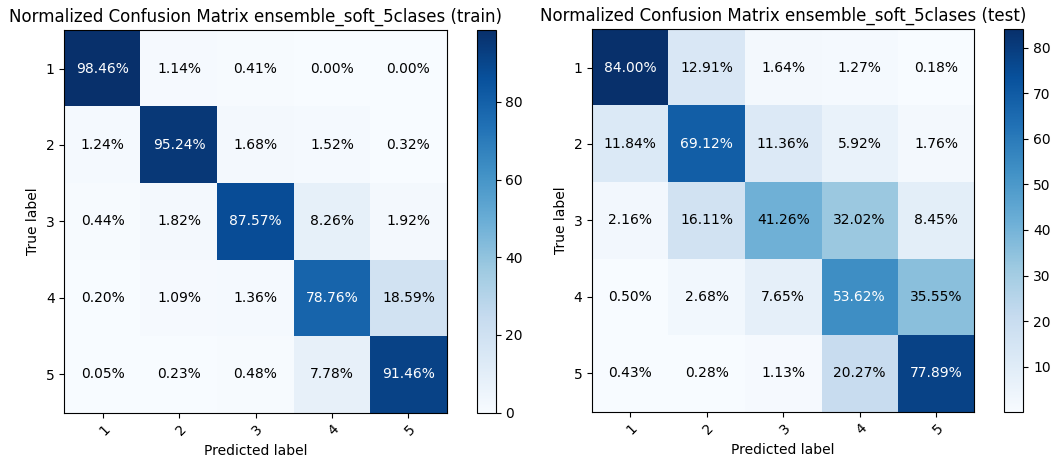

In [13]:
display(Markdown(VOTEhard_5clases_cm))
display(Markdown(VOTEsoft_5clases_cm))

Como era de esperar, al igual que los modelos base, se mejoró la clasificación de las reviews cuando se redujo la cardinalidad de las categorías a negativo, neutral, positivo.

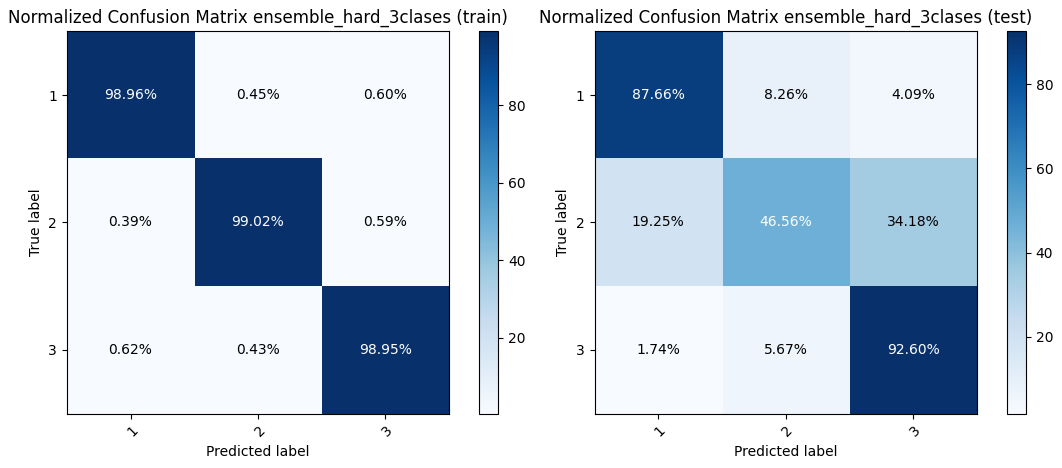

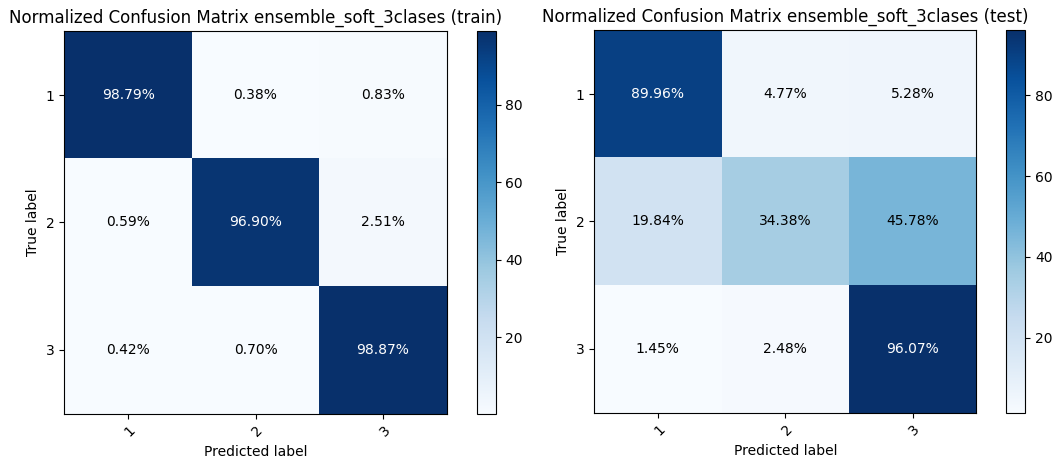

In [14]:
display(Markdown(VOTEhard_3clases_cm))
display(Markdown(VOTEsoft_3clases_cm))

Al realizar una comparación entre los modelos, se observan diferencias en su rendimiento, lo cual puede atribuirse tanto a la naturaleza del dataset como al tratamiento previo aplicado antes del entrenamiento. 

Cada modelo presenta características específicas que explican estas variaciones en los resultados obtenidos. 

Por otro lado, el proceso de búsqueda de hiperparámetros pudo haber influido significativamente en el ajuste fino (fine-tuning) de los modelos, contribuyendo también a estas discrepancias. Estos aspectos se analizan en mayor profundidad en las conclusiones.

Como se argumentó previamente, es esperable corroborar que las clases del medio (neutras) seas las que peores resultados muestren a la hora de realizar las clasificaciones tanto para 3 como para 5 clases. Algo interesante, es que logistic regression aumenta muchisimo su performance para clases neutras al simplificar el problema (3 clases). Entendemos que esto puede explicarse, en parte, a que al reducir la complejidad de los patrones a buscar este modelo más simple mejora su rendimiento.

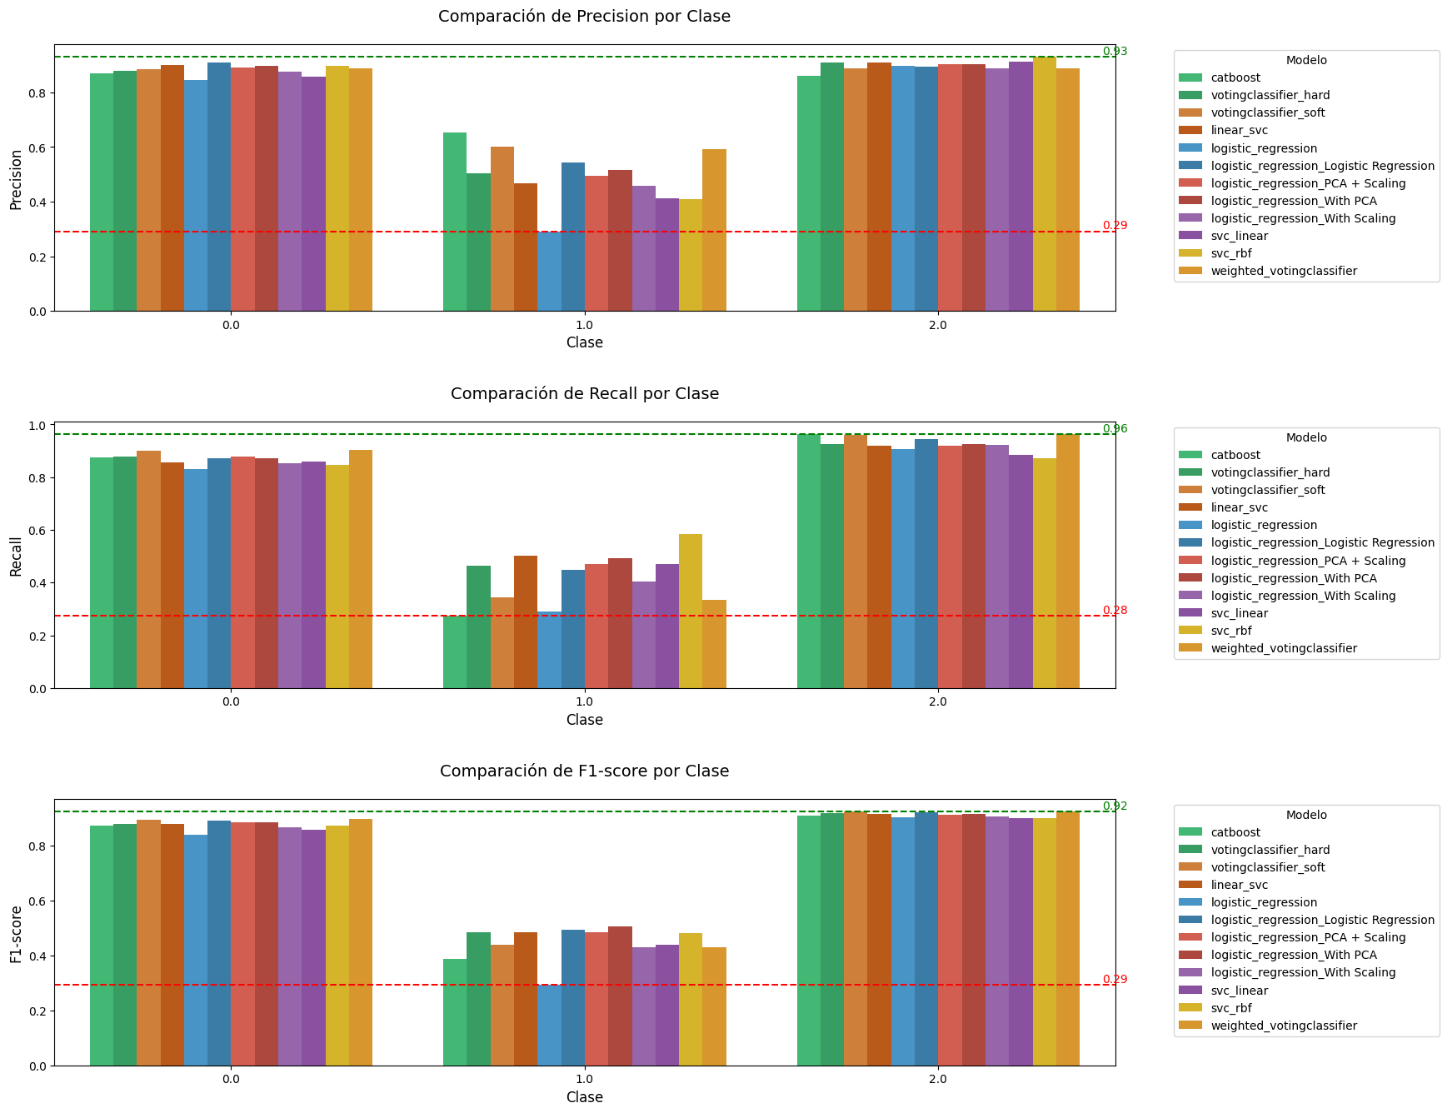

In [21]:
display(Markdown(clases_diff_3))

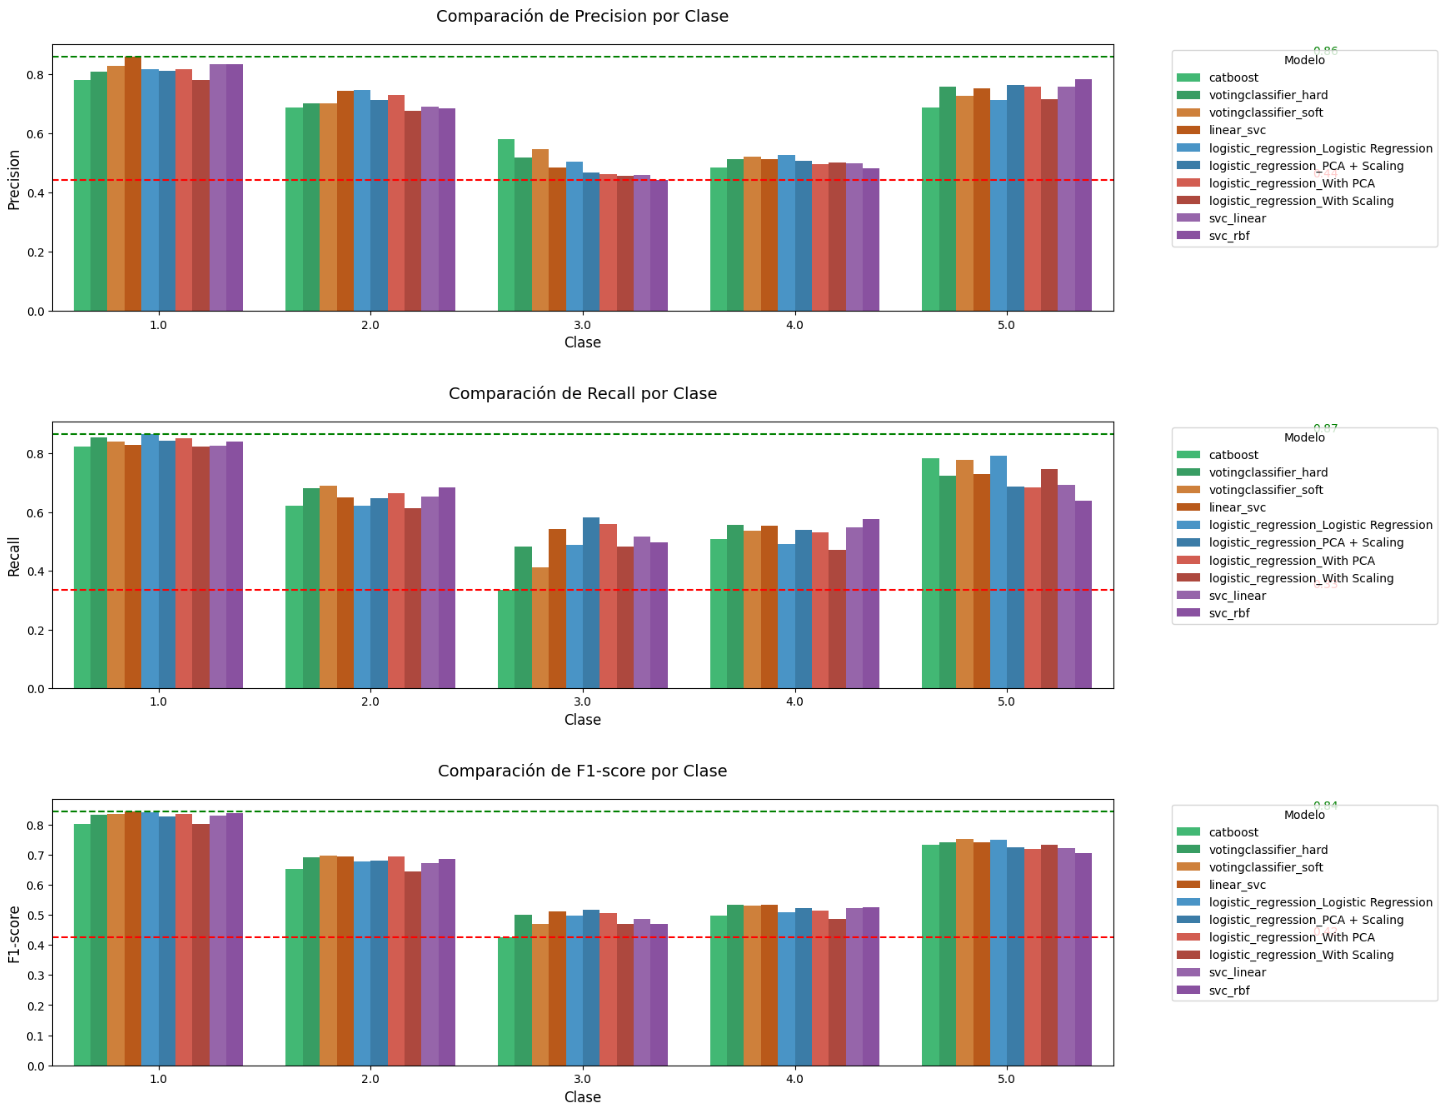

In [22]:
display(Markdown(clases_diff_5))

# Conclusiones

## Resultados para 5 Clases

Los resultados obtenidos para los modelos con 5 clases son los siguientes:

| Modelo                                | Precision | Recall | F1-Score | F1-Score Normalizado |
|---------------------------------------|-----------|--------|----------|----------------------|
| linear_svc                            | 0.673523  | 0.664554 | 0.668066 | 0.891904             |
| svc_linear                            | 0.656937  | 0.646758 | 0.650781 | 0.102206             |
| svc_rbf                               | 0.659183  | 0.639688 | 0.645685 | 0.101073             |
| catboost                              | 0.637711  | 0.641638 | 0.634027 | 0.160626             |
| votingclassifier_hard                 | 0.666336  | 0.664066 | 0.664677 | 0.103578             |
| votingclassifier_soft                 | 0.664254  | 0.668698 | 0.664945 | 0.102377             |
| logistic_regression_Logistic Regression| 0.660343  | 0.664310 | 0.660416 | 0.339130             |
| logistic_regression_PCA + Scaling     | 0.663621  | 0.651877 | 0.655858 | 0.185004             |
| logistic_regression_With PCA          | 0.661348  | 0.650171 | 0.654102 | 0.168062             |
| logistic_regression_With Scaling      | 0.634244  | 0.636763 | 0.634901 | 0.327033             |

### Mejor Modelo por F1-Score:
El mejor modelo en cuanto a **F1-Score ponderado** es **`linear_svc`** con un valor de **0.6681**.

### Mejor Modelo por Relación Score/Tiempo:
El mejor modelo en cuanto a la **relación score/tiempo** es **`linear_svc`** con un **F1-Score normalizado** de **0.8919**.

### Mejor Modelo para Predecir la Clase Más Baja:
Para identificar la clase más baja, se debe observar el modelo que presenta el mejor desempeño la clasificación dentro de la matriz de confusión. **`logistic_regression`** (ver notebook **aux_inference_model_compare.ipynb**) muestra el mejor desempeño en este sentido, ya que su TP es el más alto entre todos los modelos con **86.55%**. Destacamos este resultado en particular dado que entendemos que clasificar como positiva una review negativa podría costar más caro en un sistema de automatización que muestre en portales buenas calificaciones y comentarios.

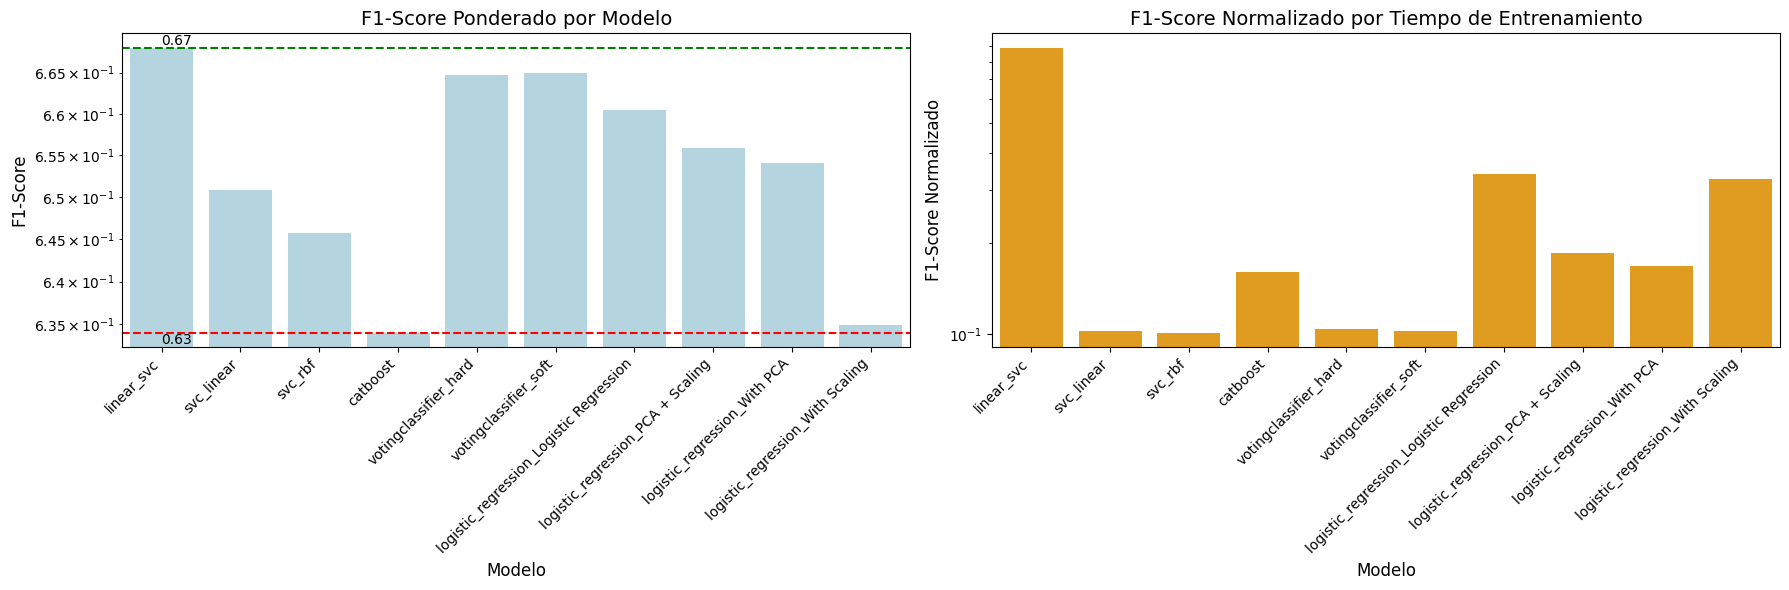

In [7]:
display(Markdown(compare_5clases))

## Resultados para 3 Clases

Los resultados obtenidos para los modelos con 3 clases son los siguientes:

| Modelo                                | Precision | Recall | F1-Score | F1-Score Normalizado |
|---------------------------------------|-----------|--------|----------|----------------------|
| linear_svc                            | 0.852448  | 0.848367 | 0.850136 | 1.099765             |
| svc_linear                            | 0.834873  | 0.825695 | 0.829894 | 0.142823             |
| svc_rbf                               | 0.856050  | 0.828864 | 0.839775 | 0.138093             |
| catboost                              | 0.837429  | 0.852267 | 0.833550 | 0.209551             |
| votingclassifier_hard                 | 0.850902  | 0.854705 | 0.852670 | 0.139431             |
| votingclassifier_soft                 | 0.851460  | 0.866650 | 0.853827 | 0.139164             |
| logistic_regression_Logistic Regression| 0.854962  | 0.862262 | 0.857553 | 0.497174             |
| logistic_regression_PCA + Scaling     | 0.849730  | 0.852267 | 0.850904 | 0.332032             |
| logistic_regression_With PCA          | 0.853615  | 0.855924 | 0.854614 | 0.350938             |
| logistic_regression_With Scaling      | 0.832266  | 0.838859 | 0.835096 | 0.467799             |


### Mejor Modelo por F1-Score:
El mejor modelo en cuanto a **F1-Score ponderado** es **`logistic_regression_Logistic Regression`** con un valor de **0.8576**.

### Mejor Modelo por Relación Score/Tiempo:
El mejor modelo en cuanto a la **relación score/tiempo** es **`linear_svc`** con un **F1-Score normalizado** de **1.0998**.

### Mejor Modelo para Predecir la Clase Más Baja:
Para identificar la clase más baja, se debe observar el modelo que presenta el mejor desempeño la clasificación dentro de la matriz de confusión. **`votingclassifier_soft`** (ver notebook **aux_inference_model_compare.ipynb**) muestra el mejor desempeño en este sentido, ya que su TP es el más alto entre todos los modelos con **89.96%**.

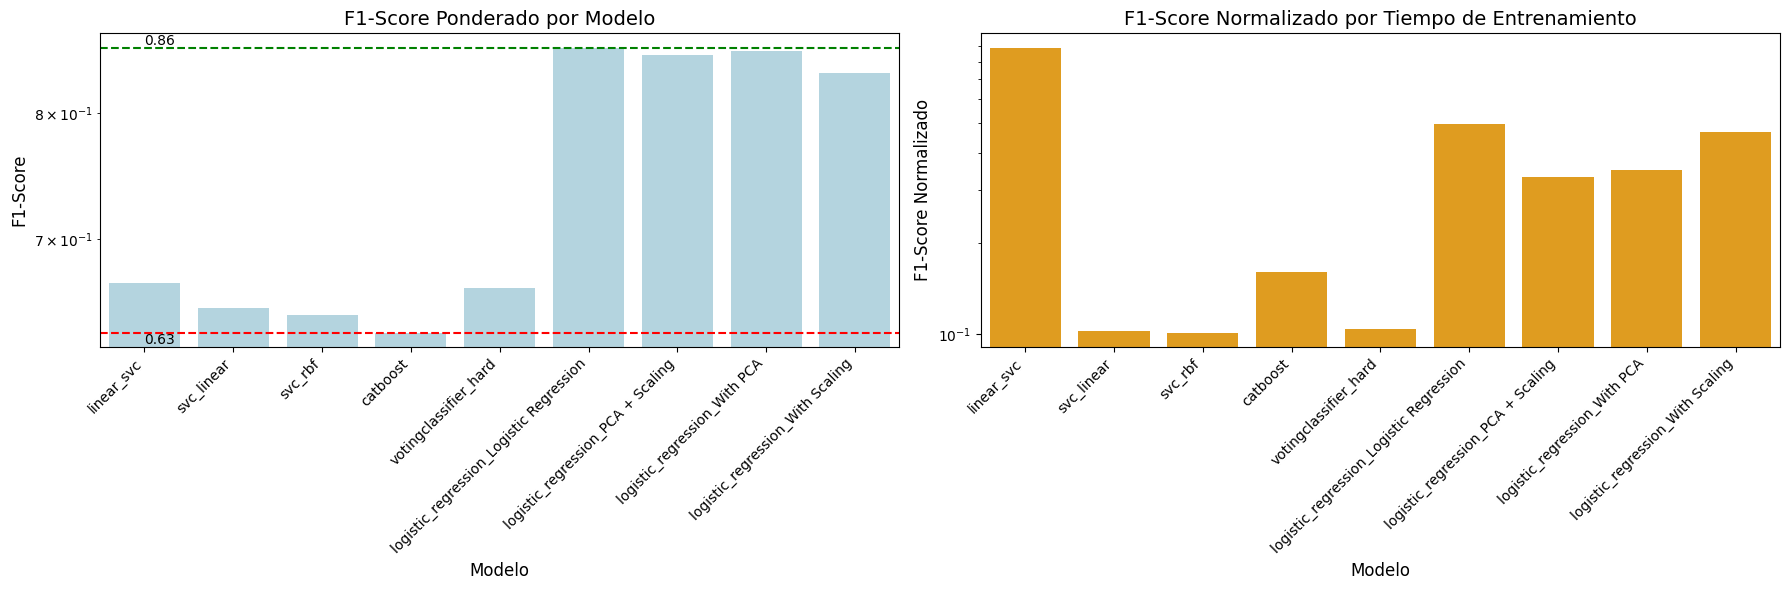

In [8]:
display(Markdown(compare_3clases))

## Conclusión General

- Para **5 clases**, el modelo **`linear_svc`** es el que mejor combina **F1-Score ponderado** y **relación score/tiempo de entrenamiento**.
- Para **3 clases**, el modelo **`logistic_regression_Logistic Regression`** es el que alcanza el mejor **F1-Score ponderado**, mientras que **`linear_svc`** sigue siendo el mejor en términos de **relación score/tiempo de entrenamiento**.
- En ambos casos, los modelos que mejor predicen la clase más baja son **`logistic_regression`** para 5 clases y **`votingclassifier_soft`** para 3 clases, basándonos en su alta consistencia y desempeño particular. Este parámetro puede ser clave donde el problema sea detectar con confianza las reviews negativas vs el resto.

Para este dataset finalmente los mejores modelos son los más simples. Esta es una situación que puede ser explicada por varias razones por las que los modelos lineales más simples (como regresión logística y SVC lineal) podrían superar a modelos más complejos como CatBoost:

1. Naturaleza de los Datos de Texto:
- Los datos de texto suelen existir en espacios de alta dimensionalidad (después de la vectorización)
- Los problemas de clasificación de texto pueden ser linealmente separables en este espacio de alta dimensionalidad
- Las reseñas frecuentemente tienen patrones lingüísticos claros que pueden ser capturados bien por relaciones lineales

2. La "Maldición de la Dimensionalidad":
- Con datos de texto de alta dimensionalidad, los modelos más simples pueden funcionar mejor porque son menos propensos al overfitting
- Los modelos complejos pueden "perderse" en el espacio de alta dimensionalidad y no encontrar los patrones necesarios
- Los modelos lineales pueden ser más robustos en escenarios de alta dimensionalidad

3. Volumen y Calidad de Datos:
- Modelos complejos como CatBoost necesitan más datos para aprender patrones significativos
- Los modelos lineales necesitan menos datos para converger a buenas soluciones

4. Complejidad del Problema:
- La clasificación en este caso puntual podría ser inherentemente más lineal de lo que esperabamos

5. Feature Engineering:
- El preprocesamiento podría haber hecho el problema más linealmente separable (t-SNE daba algunos indicios de esto)

Ideas para el futuro:
1. Mejorar la estrategia de busqueda de hiperparámetros para analizar si se pueden obtener mejores resutlados con los modelos mas complejos
2. No pre procesar tanto los datos previamente para modelos como CatBoost ya que podríamos estar sesgando o quitando información que el modelo podría necesitar para mejorar sus resultados
3. Considerar métodos de ensemble combinando con modelos simples
4. Realizar la misma tarea de clasificación con modelos SoTA basados en redes neuronales para entender que tan lejos estamos de los "mejores" resultados

# Auxiliar

In [20]:
from lib.utils import *
import io
import base64
from PIL import Image
from IPython.display import display, Markdown


# PIPELINE
image_path = "diagrams/preprocessing_spanish.png"
base64_string = encode_image_to_base64(image_path)
preprocessing = f'![Text_Pipeline](data:image/png;base64,{base64_string})'

# WORDCLOUD
image_path = "img/word_cloud.png"
base64_string = encode_image_to_base64(image_path)
word_cloud = f'![Text_Pipeline](data:image/png;base64,{base64_string})'

# PIPELINE
image_path = "img/pre_processing_classes.png"
base64_string = encode_image_to_base64(image_path)
pre_processing_classes = f'![Text_Pipeline](data:image/png;base64,{base64_string})'

# PIPELINES CATBOOST SVC
image_path = "img/catboost_svc_pipelines.png"
base64_string = encode_image_to_base64(image_path)
catboost_svc_pipelines = f'![Text_Pipeline](data:image/png;base64,{base64_string})'


# LOGISTIC REGRESSION 
image_path = "img/logistic_regression.png"
base64_string = encode_image_to_base64(image_path)
 
# Decode the base64 string
image_data = base64.b64decode(base64_string)
# Open the image using PIL
image = Image.open(io.BytesIO(image_data))
# Resize the image
new_size = (900, 900)  # Set the new size (width, height)
resized_image = image.resize(new_size)
# Convert the resized image back to base64
buffered = io.BytesIO()
resized_image.save(buffered, format="PNG")
resized_base64_string = base64.b64encode(buffered.getvalue()).decode()
logistic_regression = f'![Text_Pipeline](data:image/png;base64,{resized_base64_string})'

# LOGISTIC REGRESSION PIPELINE
image_path = "diagrams/training_grid_pipeline_spanish.png"
base64_string = encode_image_to_base64(image_path)
logistic_regression_pipeline = f'![Text_Pipeline](data:image/png;base64,{base64_string})'

# LOGISTIC REGRESSION BEST
image_path = "img/logistic_regression_best.png"
base64_string = encode_image_to_base64(image_path)
# Decode the base64 string
image_data = base64.b64decode(base64_string)
# Open the image using PIL
image = Image.open(io.BytesIO(image_data))
# Resize the image
new_size = (1200, 900)  # Set the new size (width, height)
resized_image = image.resize(new_size)
# Convert the resized image back to base64
buffered = io.BytesIO()
resized_image.save(buffered, format="PNG")
resized_base64_string = base64.b64encode(buffered.getvalue()).decode()
logistic_regression_best = f'![Text_Pipeline](data:image/png;base64,{resized_base64_string})'

# LOGISTIC REGRESSION FEATURES
image_path = "img/logistic_regression_features.png"
base64_string = encode_image_to_base64(image_path)
# Decode the base64 string
image_data = base64.b64decode(base64_string)
# Open the image using PIL
image = Image.open(io.BytesIO(image_data))
# Resize the image
new_size = (1200, 900)  # Set the new size (width, height)
resized_image = image.resize(new_size)
# Convert the resized image back to base64
buffered = io.BytesIO()
resized_image.save(buffered, format="PNG")
resized_base64_string = base64.b64encode(buffered.getvalue()).decode()
# Display the resized image in markdown
logistic_regression_features = f'![Text_Pipeline](data:image/png;base64,{resized_base64_string})'

# LOGISTIC REGRESSION FEATURES 2
image_path = "img/compare_5clases.png"
base64_string = encode_image_to_base64(image_path)
logistic_regression_features_2 = f'![Text_Pipeline](data:image/png;base64,{base64_string})'

# TSNE
image_path = "img/tsne_clases.png"
base64_string = encode_image_to_base64(image_path)
# Decode the base64 string
image_data = base64.b64decode(base64_string)
# Open the image using PIL
image = Image.open(io.BytesIO(image_data))
# Resize the image
new_size = (900, 900)  # Set the new size (width, height)
resized_image = image.resize(new_size)
# Convert the resized image back to base64
buffered = io.BytesIO()
resized_image.save(buffered, format="PNG")
resized_base64_string = base64.b64encode(buffered.getvalue()).decode()
# Display the resized image in markdown
tsne = f'![Text_Pipeline](data:image/png;base64,{resized_base64_string})'

# COMPARACIÓN 5 CLASES
image_path = "img/compare_5clases.png"
base64_string = encode_image_to_base64(image_path)
compare_5clases = f'![Text_Pipeline](data:image/png;base64,{base64_string})'

# COMPARACIÓN 3 CLASES
image_path = "img/compare_3clases.png"
base64_string = encode_image_to_base64(image_path)
compare_3clases = f'![Text_Pipeline](data:image/png;base64,{base64_string})'

# CM CATBOOST 3 CLASES
image_path = "img/catboost_3clases.png"
catboost_3clases_b64 = encode_image_to_base64(image_path)
catboost_3clases_cm = f'![Text_Pipeline](data:image/png;base64,{catboost_3clases_b64})'

# CM CATBOOST 5 CLASES
image_path = "img/catboost_5clases.png"
catboost_5clases_b64 = encode_image_to_base64(image_path)
catboost_5clases_cm = f'![Text_Pipeline](data:image/png;base64,{catboost_5clases_b64})'

# CM LINEARSVC 3 CLASES
image_path = "img/LinearSVC_3clases.png"
LinearSVC_3clases_b64 = encode_image_to_base64(image_path)
LinearSVC_3clases_cm = f'![Text_Pipeline](data:image/png;base64,{LinearSVC_3clases_b64})'

# CM LINEARSVC 5 CLASES
image_path = "img/LinearSVC_5clases.png"
LinearSVC_5clases_b64 = encode_image_to_base64(image_path)
LinearSVC_5clases_cm = f'![Text_Pipeline](data:image/png;base64,{LinearSVC_5clases_b64})'

# CM SVCLINEAR 3 CLASES
image_path = "img/SVCLinear_3clases.png"
SVCLinear_3clases_b64 = encode_image_to_base64(image_path)
SVCLinear_3clases_cm = f'![Text_Pipeline](data:image/png;base64,{SVCLinear_3clases_b64})'

# CM SVCLINEAR 5 CLASES
image_path = "img/SVCLinear_5clases.png"
SVCLinear_5clases_b64 = encode_image_to_base64(image_path)
SVCLinear_5clases_cm = f'![Text_Pipeline](data:image/png;base64,{SVCLinear_5clases_b64})'

# CM SVCRBF 3 CLASES
image_path = "img/SVCrbf_3clases.png"
SVCrbf_3clases_b64 = encode_image_to_base64(image_path)
SVCrbf_3clases_cm = f'![Text_Pipeline](data:image/png;base64,{SVCrbf_3clases_b64})'

# CM SVCRBF 5 CLASES
image_path = "img/SVCrbf_5clases.png"
SVCrbf_5clases_b64 = encode_image_to_base64(image_path)
SVCrbf_5clases_cm = f'![Text_Pipeline](data:image/png;base64,{SVCrbf_5clases_b64})'

# CM VOTEHARD 3 CLASES
image_path = "img/VOTEhard_3clases.png"
VOTEhard_3clases_b64 = encode_image_to_base64(image_path)
VOTEhard_3clases_cm = f'![Text_Pipeline](data:image/png;base64,{VOTEhard_3clases_b64})'

# CM VOTEHARD 5 CLASES
image_path = "img/VOTEhard_5clases.png"
VOTEhard_5clases_b64 = encode_image_to_base64(image_path)
VOTEhard_5clases_cm = f'![Text_Pipeline](data:image/png;base64,{VOTEhard_5clases_b64})'

# CM VOTESOFT 3 CLASES
image_path = "img/VOTEsoft_3clases.png"
VOTEsoft_3clases_b64 = encode_image_to_base64(image_path)
VOTEsoft_3clases_cm = f'![Text_Pipeline](data:image/png;base64,{VOTEsoft_3clases_b64})'

# CM VOTESOFT 5 CLASES
image_path = "img/VOTEsoft_5clases.png"
VOTEsoft_5clases_b64 = encode_image_to_base64(image_path)
VOTEsoft_5clases_cm = f'![Text_Pipeline](data:image/png;base64,{VOTEsoft_5clases_b64})'

# COMPARE CLASES
image_path = "img/compare_clases_3.png"
clases_diff_b64 = encode_image_to_base64(image_path)
clases_diff_3 = f'![Text_Pipeline](data:image/png;base64,{clases_diff_b64})'

image_path = "img/compare_clases_5.png"
clases_diff_b64 = encode_image_to_base64(image_path)
clases_diff_5 = f'![Text_Pipeline](data:image/png;base64,{clases_diff_b64})'

